# 客户消费行为与偏好全景分析报告

## 一. 分析目的
通过对客户购物行为数据进行多维度分析，旨在深入理解消费者画像特征、产品偏好、购买习惯及支付方式等关键因素，挖掘不同用户群体的行为差异与潜在规律。最终为精准营销策略制定、产品品类优化、库存管理以及用户忠诚度提升提供数据驱动的决策支持，进一步提升客户体验与商业效益。

## 二. 数据概览

In [1]:

#导入库
import numpy as np # 导入NumPy库，用于科学计算
import pandas as pd # 导入Pandas库，用于数据处理和分析
import matplotlib.pyplot as plt # 导入Matplotlib的pyplot模块，用于绘图
import seaborn as sns # 导入Seaborn库，基于Matplotlib的统计可视化库
import datetime # 导入datetime库，用于处理日期和时间
import warnings # 导入warnings库，用于控制警告信息
warnings.filterwarnings('ignore') # 忽略所有警告信息，避免输出不必要的警告
%matplotlib inline 
# JupyterLab魔法命令，使图表直接显示在笔记本中

# 设置Matplotlib的pyplot模块默认字体为黑体（SimHei），以支持中文显示
plt.rcParams['font.sans-serif'] = 'SimHei'

In [5]:
data = pd.read_csv('shopping_trends.csv')
data

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


## 三. 数据清理

In [6]:
data.info()
data['Customer ID'] = data['Customer ID'].astype(object)
# 检查数据类型
print(data['Customer ID'].dtype)
# 查看前几行数据
print(data['Customer ID'].head())


# 查找重复值
print(data.duplicated().sum())
# 删除重复记录
data.drop_duplicates(keep='first',inplace=True)


data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


## 四. 分析维度

分析维度围绕以下六大核心方向展开：
一是消费者画像分析，包括年龄区间与购买力群体特征、性别差异与消费水平对比，以及高消费州/地区分布与地域偏好；
二是产品与品类分析，涵盖热门商品类别、品类平均消费金额、颜色偏好以及季节性销售波动；
三是购买行为分析，聚焦客单价分布、折扣与促销码的使用行为及其对消费金额的影响，并比较订阅用户与非订阅用户的消费差异；
四是支付与配送偏好分析，包括常用支付方式、配送类型偏好，以及配送方式与消费金额、购买频次之间的关联；
五是复购与忠诚度分析，涉及历史购买次数分布、购买频率划分，并挖掘高复购用户的人口属性与行为特征；
六是用户反馈分析，围绕评分分布展开，探索高/低分订单的商品与品类共性，以及评分与消费金额、折扣使用等因素的相关性。

## 五. 分析内容

## 5.1 消费者画像分析

### 5.1.1 年龄分布

In [8]:

print("年龄描述性统计:")
print(data['Age'].describe())

年龄描述性统计:
count    3900.000000
mean       44.068462
std        15.207589
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Age, dtype: float64


In [9]:

# 创建年龄段
bins = [17, 25, 35, 45, 55, 65, 70] # 从年龄描述性统计中可知年龄最小值为18，不用设置0-18岁的区间，65岁以上的分组端点值设置为年龄的最大值70
labels = ['18-25岁', '26-35岁', '36-45岁', '46-55岁', '56-65岁', '65岁以上']
data['Age Group'] = pd.cut(data['Age'], bins=bins, labels=labels, right=True) # 分段区间左开右闭

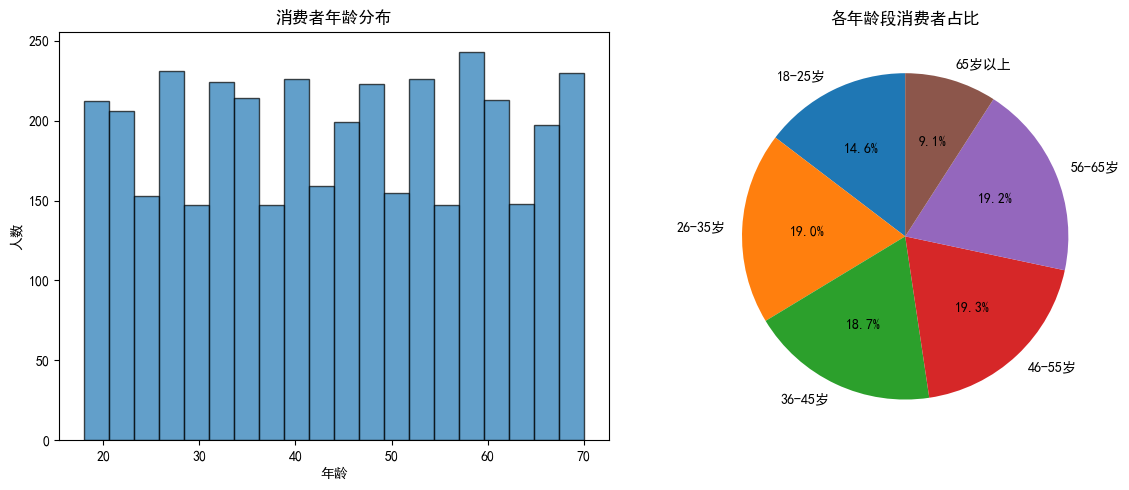

In [10]:

plt.figure(figsize=(12, 5)) # 创建图形对象，设置图形大小为12x5英寸

# 子图1: 年龄分布直方图
plt.subplot(1, 2, 1)  # 创建1行2列的子图布局，并选择第1个子图
plt.hist(data['Age'], bins=20, edgecolor='black', alpha=0.7) 
# plt.hist()参数说明：
# data['Age']：使用的数据列;
# bins=20：将数据分成20个区间（柱状）;
# edgecolor='black'：设置柱状边缘颜色为黑色;
# alpha=0.7：设置透明度为0.7，使图形更美观
plt.title('消费者年龄分布')
plt.xlabel('年龄')
plt.ylabel('人数')

# 子图2: 各年龄段人数占比
plt.subplot(1, 2, 2)
age_group_counts = data['Age Group'].value_counts().sort_index() # 计算每个年龄段的消费者数量,按年龄段的索引排序（确保饼图顺序一致）
# plt.pie() 参数说明：
# age_group_counts：饼图各部分的数值
# labels=age_group_counts.index：使用年龄段标签作为饼图标签
# autopct='%1.1f%%'：在饼图上显示百分比，保留一位小数
# startangle=90：从90度角开始绘制（12点钟方向）

plt.pie(age_group_counts, labels=age_group_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('各年龄段消费者占比')

plt.tight_layout() # 自动调整子图参数，使之填充整个图像区域
plt.show() # 显示图形

In [11]:

# 各年龄段消费能力分析
age_group_analysis = data.groupby('Age Group')['Purchase Amount (USD)'].agg(['mean', 'median', 'count']).round(2)
age_group_analysis.columns = ['平均消费金额', '消费金额中位数', '人数']
print("\n各年龄段消费能力分析:")
print(age_group_analysis)


各年龄段消费能力分析:
           平均消费金额  消费金额中位数   人数
Age Group                      
18-25岁      60.65     62.0  571
26-35岁      59.76     60.0  742
36-45岁      59.31     59.0  729
46-55岁      60.58     62.0  753
56-65岁      59.14     58.5  750
65岁以上       58.88     59.0  355


### 5.1.2 性别分布

In [12]:

# 男女比例分析
gender_counts = data['Gender'].value_counts()
gender_ratio = gender_counts['Male'] / gender_counts['Female']
print(f"男女比例: {gender_ratio:.2f}:1")

男女比例: 2.12:1


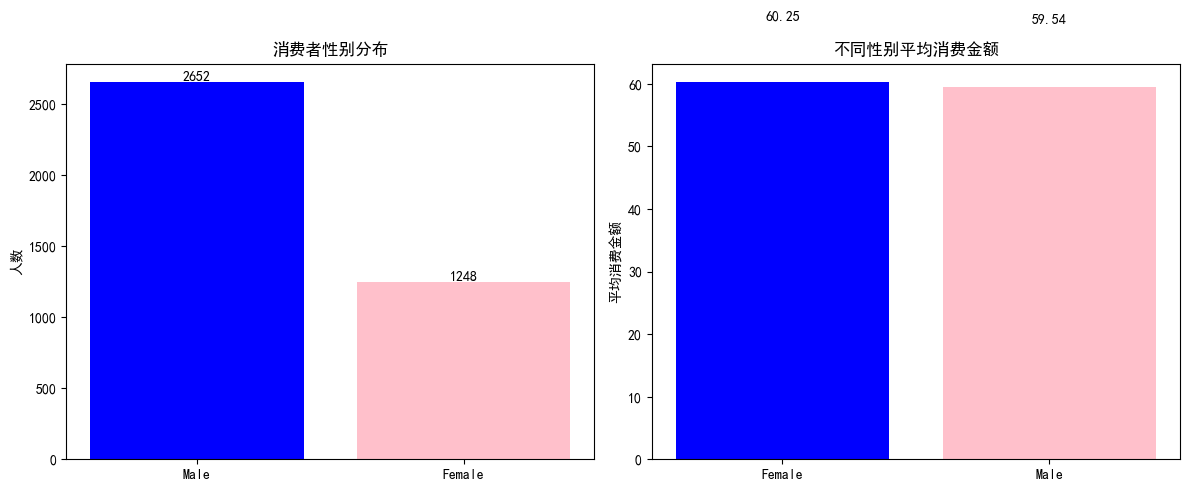

In [13]:

# 绘制性别分布图
plt.figure(figsize=(12, 5))

# 子图1: 性别人数对比
plt.subplot(1, 2, 1)
plt.bar(gender_counts.index, gender_counts.values, color=['blue', 'pink'])
plt.title('消费者性别分布')
plt.ylabel('人数')

# 在柱状图上添加数值标签
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 10, str(v), ha='center')

# 子图2: 性别消费金额对比
plt.subplot(1, 2, 2)
gender_amount = data.groupby('Gender')['Purchase Amount (USD)'].mean()
plt.bar(gender_amount.index, gender_amount.values, color=['blue', 'pink'])
plt.title('不同性别平均消费金额')
plt.ylabel('平均消费金额')

# 在柱状图上添加数值标签
for i, v in enumerate(gender_amount.values):
    plt.text(i, v + 10, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

In [14]:

# 性别消费差异统计检验
from scipy import stats

male_amounts = data[data['Gender'] == 'Male']['Purchase Amount (USD)']
female_amounts = data[data['Gender'] == 'Female']['Purchase Amount (USD)']

t_stat, p_value = stats.ttest_ind(male_amounts, female_amounts)
print(f"\n性别消费差异T检验: t统计量={t_stat:.3f}, p值={p_value:.3f}")

if p_value < 0.05:
    print("不同性别消费金额存在显著差异")
else:
    print("不同性别消费金额无显著差异")


性别消费差异T检验: t统计量=-0.877, p值=0.381
不同性别消费金额无显著差异


### 5.1.3 地域分布

In [15]:

# 地域消费情况分析
region_analysis = data.groupby('Location').agg({
    'Purchase Amount (USD)': [ 'sum', 'mean','count'],
    'Age': 'mean'
}).round(2)
region_analysis.columns = [ '消费总额', '平均消费金额','消费者人数', '平均年龄']
region_analysis = region_analysis.sort_values('消费总额', ascending=False)
print("各地区消费情况分析:")
print(region_analysis)

各地区消费情况分析:
                消费总额  平均消费金额  消费者人数   平均年龄
Location                                  
Montana         5784   60.25     96  43.82
Illinois        5617   61.05     92  43.28
California      5605   59.00     95  42.66
Idaho           5587   60.08     93  43.30
Nevada          5514   63.38     87  43.61
Alabama         5261   59.11     89  44.31
New York        5257   60.43     87  43.93
North Dakota    5220   62.89     83  43.77
West Virginia   5174   63.88     81  42.54
Nebraska        5172   59.45     87  42.67
New Mexico      5014   61.90     81  44.02
Minnesota       4977   56.56     88  45.48
Pennsylvania    4926   66.57     74  42.97
Mississippi     4883   61.04     80  43.26
Alaska          4867   67.60     72  43.00
Vermont         4860   57.18     85  42.60
Louisiana       4848   57.71     84  48.15
Virginia        4842   62.88     77  41.61
Arkansas        4828   61.11     79  44.10
Maryland        4795   55.76     86  46.90
Tennessee       4772   61.97     77  44.05


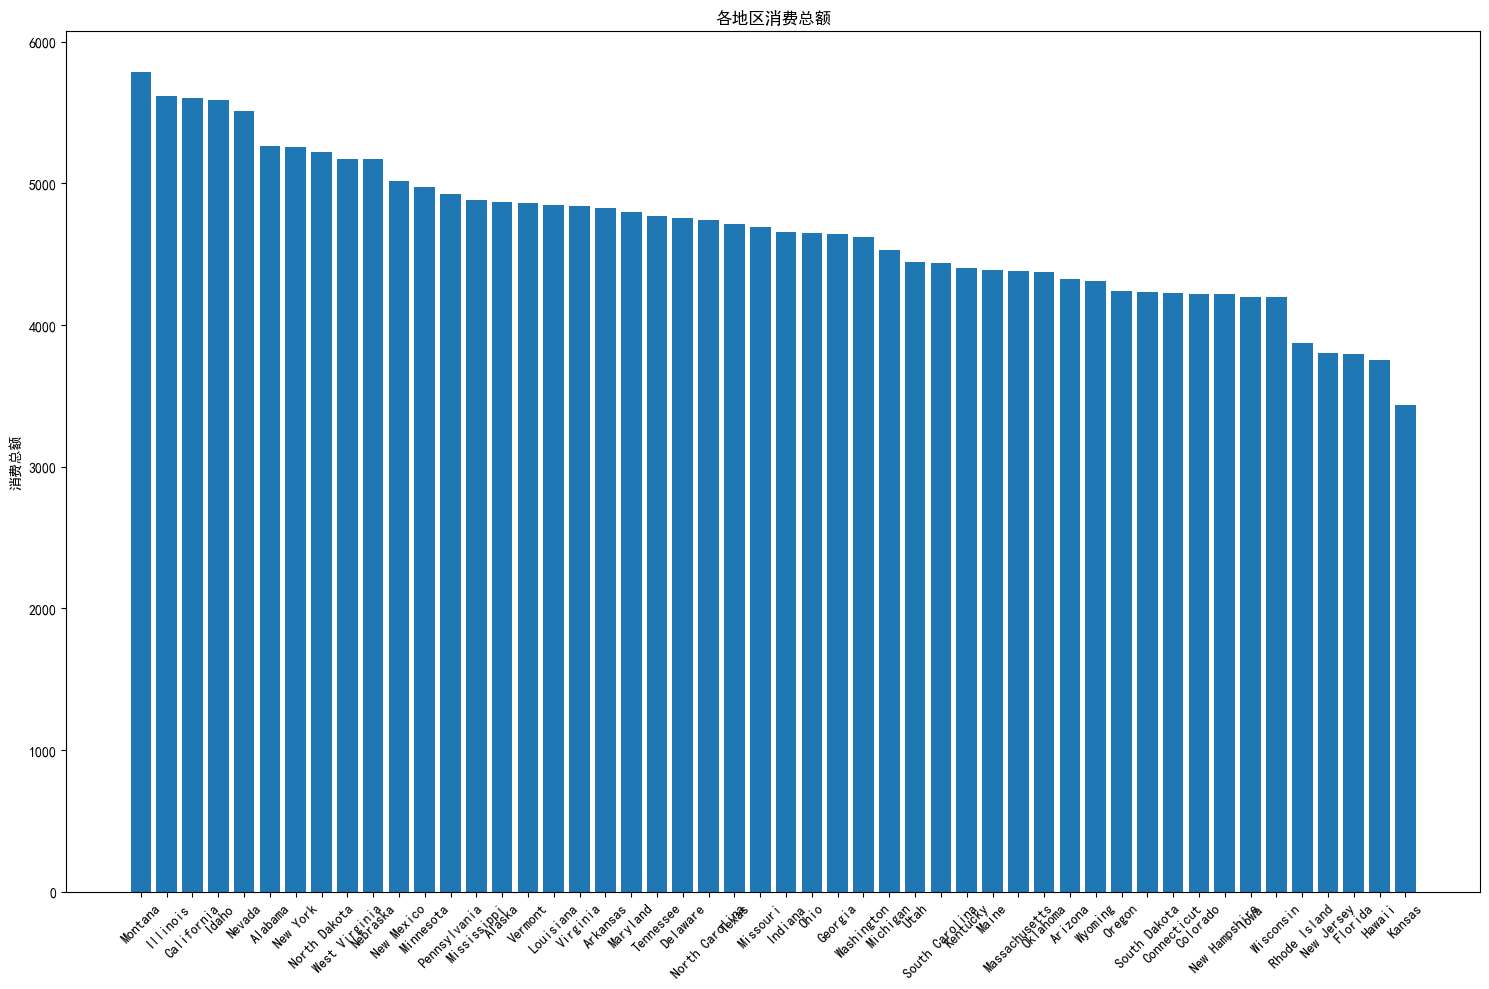

In [16]:

# 绘制各地区消费总额
plt.figure(figsize=(15, 10))

region_total = data.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
plt.bar(region_total.index, region_total.values)
plt.title('各地区消费总额')
plt.xticks(rotation=45)
plt.ylabel('消费总额')

plt.tight_layout()
plt.show()


In [17]:

# 地域偏好分析 - 计算各地区消费占比
total_consumption = data['Purchase Amount (USD)'].sum()
region_analysis['消费占比'] = (region_analysis['消费总额'] / total_consumption * 100).round(2)
region_analysis['人数占比'] = (region_analysis['消费者人数'] / len(data) * 100).round(2)

print("\n各地区消费占比分析:")
print(region_analysis[['消费占比', '人数占比']])


各地区消费占比分析:
                消费占比  人数占比
Location                  
Montana         2.48  2.46
Illinois        2.41  2.36
California      2.40  2.44
Idaho           2.40  2.38
Nevada          2.37  2.23
Alabama         2.26  2.28
New York        2.26  2.23
North Dakota    2.24  2.13
West Virginia   2.22  2.08
Nebraska        2.22  2.23
New Mexico      2.15  2.08
Minnesota       2.14  2.26
Pennsylvania    2.11  1.90
Mississippi     2.09  2.05
Alaska          2.09  1.85
Vermont         2.09  2.18
Louisiana       2.08  2.15
Virginia        2.08  1.97
Arkansas        2.07  2.03
Maryland        2.06  2.21
Tennessee       2.05  1.97
Delaware        2.04  2.21
North Carolina  2.03  2.00
Texas           2.02  1.97
Missouri        2.01  2.08
Indiana         2.00  2.03
Ohio            1.99  1.97
Georgia         1.99  2.03
Washington      1.98  1.87
Michigan        1.94  1.87
Utah            1.91  1.82
South Carolina  1.90  1.95
Kentucky        1.89  2.03
Maine           1.88  1.97
Massachusetts   

In [18]:

# 计算消费指数（人均消费相对于平均水平的比值）
overall_avg_spending =data['Purchase Amount (USD)'].mean()
region_analysis['消费指数'] = (region_analysis['平均消费金额'] / overall_avg_spending).round(2)

print("\n各地区消费指数（1=平均水平）:")
print(region_analysis['消费指数'].sort_values(ascending=False))


各地区消费指数（1=平均水平）:
Location
Alaska            1.13
Arizona           1.11
Pennsylvania      1.11
West Virginia     1.07
Nevada            1.06
Washington        1.06
Utah              1.05
Virginia          1.05
North Dakota      1.05
New Mexico        1.04
Tennessee         1.04
Michigan          1.04
Rhode Island      1.03
North Carolina    1.02
Texas             1.02
Iowa              1.02
Wyoming           1.02
Illinois          1.02
Arkansas          1.02
Massachusetts     1.02
Mississippi       1.02
Montana           1.01
South Dakota      1.01
New York          1.01
Idaho             1.01
Ohio              1.01
New Hampshire     0.99
Indiana           0.99
Nebraska          0.99
California        0.99
Alabama           0.99
Georgia           0.98
South Carolina    0.98
Oklahoma          0.98
Hawaii            0.97
Louisiana         0.97
Missouri          0.97
Vermont           0.96
Oregon            0.96
New Jersey        0.95
Minnesota         0.95
Maine             0.95
Colorad

### 综合分析与建议

消费者画像综合分析
1. 主要消费者年龄段: 46-55岁
   该年龄段特点: 人数占比19.3%
2. 性别分布: 男性2652人, 女性1248人, 比例2.12:1
3. 消费最高的地区: Montana, 占总消费2.48%
4. 消费力最强的地区: Alaska, 消费指数1.13


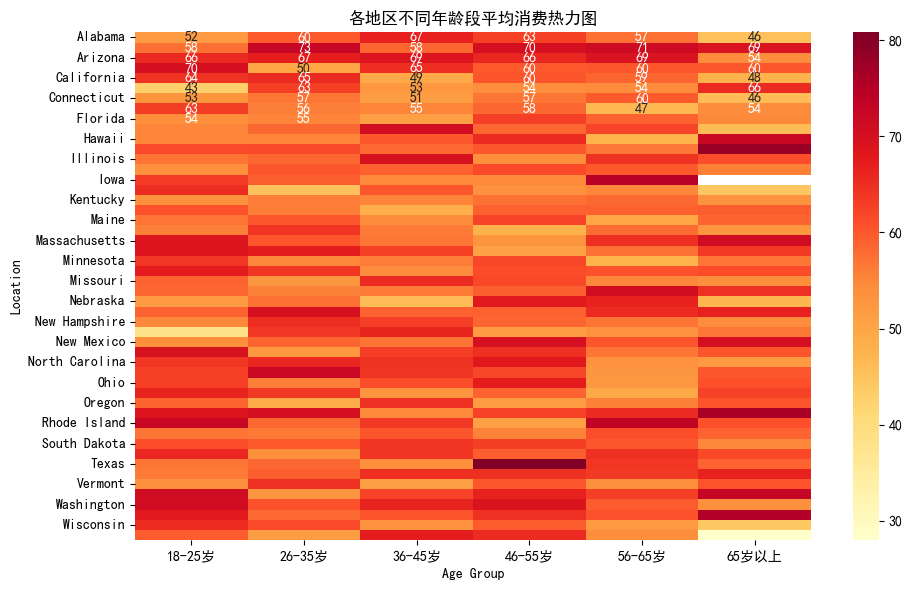

In [19]:

print("消费者画像综合分析")
print("="*150)

# 1. 主要发现 - 年龄
dominant_age_group = age_group_analysis['人数'].idxmax()
print(f"1. 主要消费者年龄段: {dominant_age_group}")
print(f"   该年龄段特点: 人数占比{age_group_counts[dominant_age_group]/len(data)*100:.1f}%")

# 2. 主要发现 - 性别
print(f"2. 性别分布: 男性{gender_counts['Male']}人, 女性{gender_counts['Female']}人, 比例{gender_ratio:.2f}:1")
if p_value < 0.05:
    higher_spender = "女性" if female_amounts.mean() > male_amounts.mean() else "男性"
    print(f"   {higher_spender}平均消费金额较高，差异显著(p={p_value:.3f})")

# 3. 主要发现 - 地域
top_region = region_total.index[0]
print(f"3. 消费最高的地区: {top_region}, 占总消费{region_analysis.loc[top_region, '消费占比']}%")

# 4. 消费指数最高的地区
highest_index_region = region_analysis['消费指数'].idxmax()
print(f"4. 消费力最强的地区: {highest_index_region}, 消费指数{region_analysis.loc[highest_index_region, '消费指数']}")

# 绘制综合热力图展示地区、年龄和消费的关系
plt.figure(figsize=(10, 6))
region_age_pivot = pd.pivot_table(data, values='Purchase Amount (USD)', index='Location', 
                                  columns='Age Group', aggfunc='mean')
sns.heatmap(region_age_pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('各地区不同年龄段平均消费热力图')
plt.tight_layout()
plt.show()

In [20]:

# 基于分析结果提出建议
print("\n营销建议:")
print("1. 目标人群定位:")
print(f"   - 重点针对{dominant_age_group}年龄段消费者进行营销")
if p_value < 0.05:
    higher_spender = "女性" if female_amounts.mean() > male_amounts.mean() else "男性"
    print(f"   {higher_spender}平均消费金额较高，差异显著(p={p_value:.3f}),可设计针对性产品")

print("\n2. 地域策略:")
print(f"   - 巩固{top_region}市场领先地位，加大投入")
print(f"   - 重点关注{highest_index_region}等高消费力地区")
print(f"   - 开发消费指数较低但人口基数大的地区市场")

print("\n3. 产品与营销策略:")
print("   - 根据不同地区消费者年龄特点设计差异化产品")
print("   - 考虑地区文化偏好设计营销活动")
print("   - 针对高消费群体推出高端产品线")


营销建议:
1. 目标人群定位:
   - 重点针对46-55岁年龄段消费者进行营销

2. 地域策略:
   - 巩固Montana市场领先地位，加大投入
   - 重点关注Alaska等高消费力地区
   - 开发消费指数较低但人口基数大的地区市场

3. 产品与营销策略:
   - 根据不同地区消费者年龄特点设计差异化产品
   - 考虑地区文化偏好设计营销活动
   - 针对高消费群体推出高端产品线


## 5.2 产品与品类分析

### 5.2.1 最受欢迎的商品类别

In [21]:

print("商品类别分析:")
print("=" * 50)

# 按类别统计购买次数
category_counts = data['Category'].value_counts()
print("\n各品类购买次数:")
print(category_counts)

# 按类别统计总销售额
category_sales = data.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
print("\n各品类总销售额:")
print(category_sales.round(2))

商品类别分析:

各品类购买次数:
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

各品类总销售额:
Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64


In [22]:

# 计算品类占比
total_sales = data['Purchase Amount (USD)'].sum()
category_share = (category_sales / total_sales * 100).round(2)
print("\n各品类销售额占比:")
for category, share in category_share.items():
    print(f"{category}: {share}%")


各品类销售额占比:
Clothing: 44.73%
Accessories: 31.83%
Footwear: 15.49%
Outerwear: 7.95%


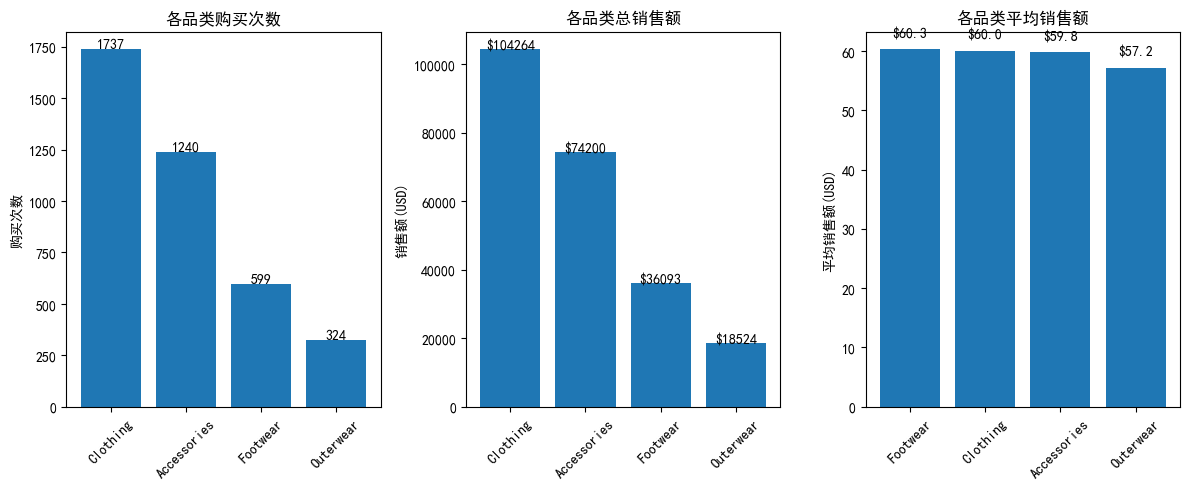

In [23]:

# 绘制品类数据图
plt.figure(figsize=(12, 5))

# 子图1: 各品类购买次数
plt.subplot(1, 3, 1)
plt.bar(category_counts.index, category_counts.values)
plt.title('各品类购买次数')
plt.xticks(rotation=45)
plt.ylabel('购买次数')

# 在柱状图上添加数值标签
for i, v in enumerate(category_counts.values):
    plt.text(i, v + 5, str(v), ha='center')

# 子图2: 各品类总销售额
plt.subplot(1, 3, 2)
plt.bar(category_sales.index, category_sales.values)
plt.title('各品类总销售额')
plt.xticks(rotation=45)
plt.ylabel('销售额(USD)')

# 在柱状图上添加数值标签
for i, v in enumerate(category_sales.values):
    plt.text(i, v + 20, f'${v:.0f}', ha='center')

# 子图3: 各品类平均销售额
category_avg_sales = data.groupby('Category')['Purchase Amount (USD)'].mean().sort_values(ascending=False)
plt.subplot(1, 3, 3)
plt.bar(category_avg_sales.index, category_avg_sales.values)
plt.title('各品类平均销售额')
plt.xticks(rotation=45)
plt.ylabel('平均销售额(USD)')

# 在柱状图上添加数值标签
for i, v in enumerate(category_avg_sales.values):
    plt.text(i, v + 2, f'${v:.1f}', ha='center')

plt.tight_layout()
plt.show()

### 5.5.5 颜色偏好分析

In [24]:

print("\n颜色偏好分析:")
print("=" * 50)

# 按颜色统计购买次数
color_counts = data['Color'].value_counts()
print("\n各颜色购买次数:")
print(color_counts)

# 按颜色统计平均销售额
color_avg_sales = data.groupby('Color')['Purchase Amount (USD)'].mean().sort_values(ascending=False)
print("\n各颜色平均销售额:")
print(color_avg_sales.round(2))


颜色偏好分析:

各颜色购买次数:
Color
Olive        177
Yellow       174
Silver       173
Teal         172
Green        169
Black        167
Cyan         166
Violet       166
Gray         159
Maroon       158
Orange       154
Charcoal     153
Pink         153
Magenta      152
Blue         152
Purple       151
Peach        149
Red          148
Beige        147
Indigo       147
Lavender     147
Turquoise    145
White        142
Brown        141
Gold         138
Name: count, dtype: int64

各颜色平均销售额:
Color
Green        65.70
White        62.64
Gray         62.49
Cyan         61.89
Violet       61.72
Gold         61.01
Orange       60.89
Teal         60.81
Charcoal     60.63
Pink         60.59
Beige        60.41
Purple       60.01
Maroon       59.53
Red          59.32
Yellow       59.24
Peach        59.19
Lavender     59.13
Brown        59.06
Black        58.40
Olive        58.15
Magenta      57.13
Blue         56.95
Silver       56.83
Indigo       56.25
Turquoise    55.61
Name: Purchase Amount (USD), dty

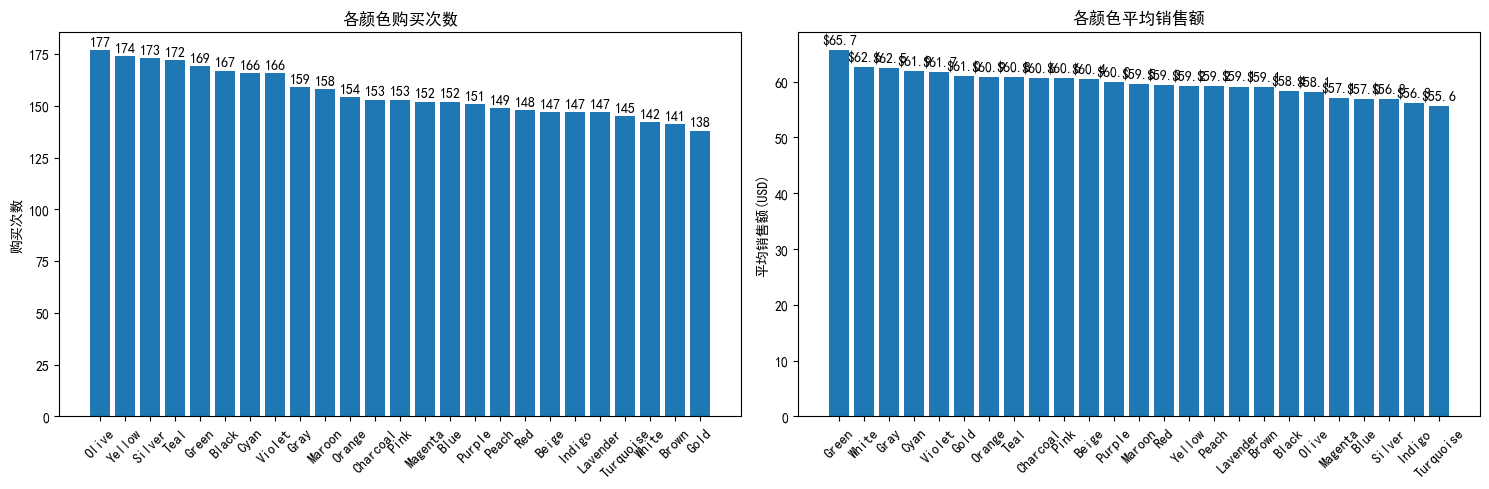

In [25]:

# 绘制颜色偏好分析图
plt.figure(figsize=(15, 5))

# 子图1: 各颜色购买次数
plt.subplot(1, 2, 1)
plt.bar(color_counts.index, color_counts.values)
plt.title('各颜色购买次数')
plt.xticks(rotation=45)
plt.ylabel('购买次数')

# 在柱状图上添加数值标签
for i, v in enumerate(color_counts.values):
    plt.text(i, v + 2, str(v), ha='center')

# 子图2: 各颜色平均销售额
plt.subplot(1, 2, 2)
plt.bar(color_avg_sales.index, color_avg_sales.values)
plt.title('各颜色平均销售额')
plt.xticks(rotation=45)
plt.ylabel('平均销售额(USD)')

# 在柱状图上添加数值标签
for i, v in enumerate(color_avg_sales.values):
    plt.text(i, v + 1, f'${v:.1f}', ha='center')

plt.tight_layout()
plt.show()

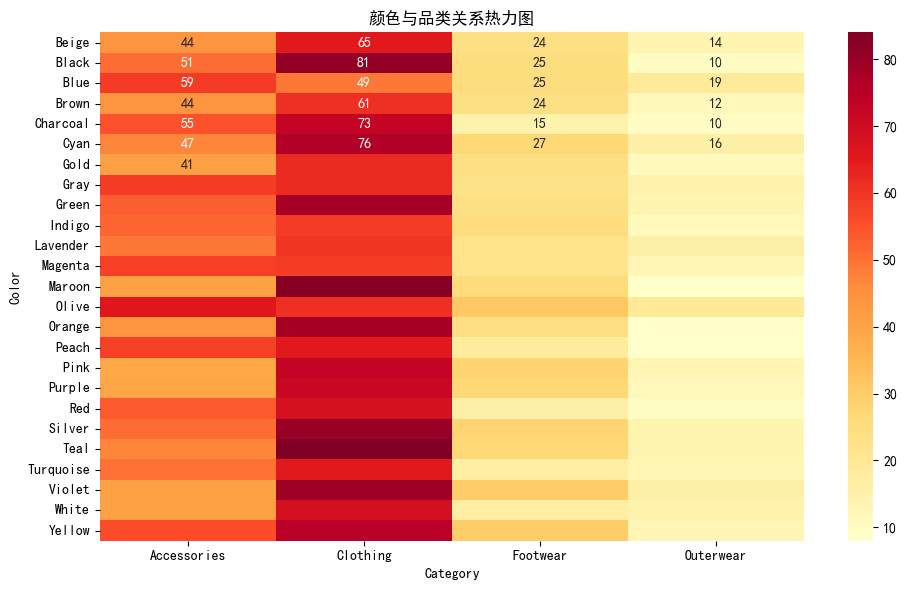

In [26]:

# 颜色与品类的关系分析
color_category = pd.crosstab(data['Color'], data['Category'])

# 绘制热力图展示颜色与品类的关系
plt.figure(figsize=(10, 6))
sns.heatmap(color_category, annot=True, fmt='d', cmap='YlOrRd')
plt.title('颜色与品类关系热力图')
plt.tight_layout()
plt.show()


### 5.2.3 季节性销售趋势

In [27]:

# 按季节统计购买次数
season_counts = data['Season'].value_counts()
print("\n各季节购买次数:")
print(season_counts)

# 按季节统计销售额
season_sales = data.groupby('Season')['Purchase Amount (USD)'].sum()
print("\n各季节总销售额:")
print(season_sales.round(2))

# 按季节统计平均销售额
season_avg_sales = data.groupby('Season')['Purchase Amount (USD)'].mean()
print("\n各季节平均销售额:")
print(season_avg_sales.round(2))


各季节购买次数:
Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64

各季节总销售额:
Season
Fall      60018
Spring    58679
Summer    55777
Winter    58607
Name: Purchase Amount (USD), dtype: int64

各季节平均销售额:
Season
Fall      61.56
Spring    58.74
Summer    58.41
Winter    60.36
Name: Purchase Amount (USD), dtype: float64


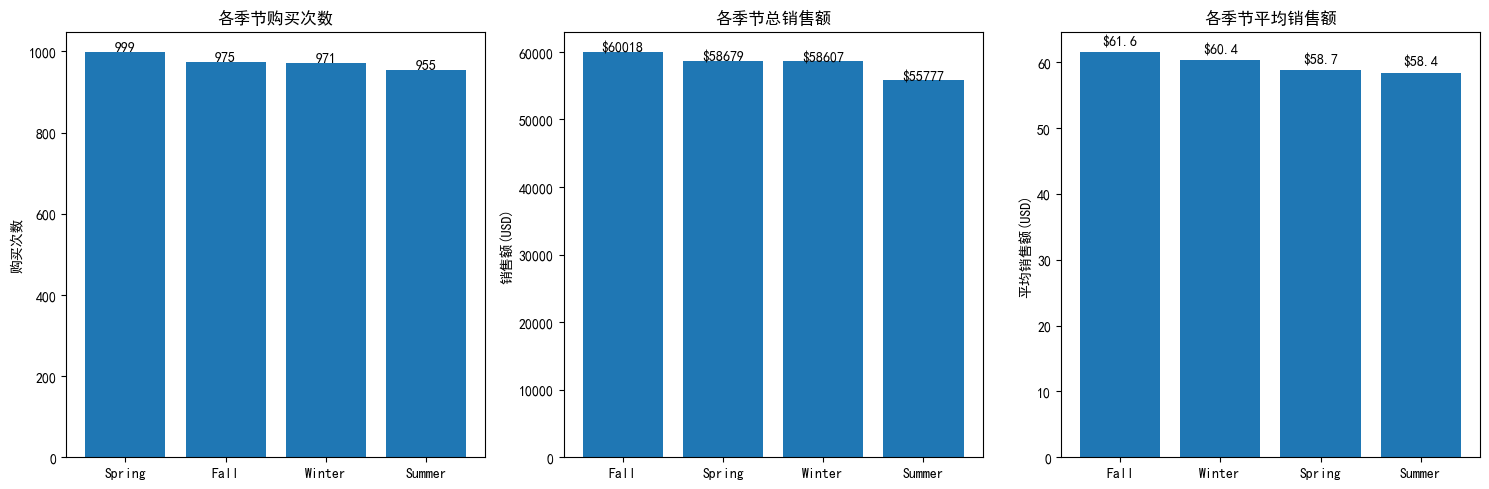

In [28]:

# 绘制季节性销售趋势图
plt.figure(figsize=(15, 5))

# 子图1: 各季节购买次数
plt.subplot(1, 3, 1)
season_counts_sorted = season_counts.sort_values(ascending=False) # 按购买次数降序排序
x_labels = [str(label) for label in season_counts_sorted.index]
plt.bar(x_labels,season_counts_sorted.values)
plt.title('各季节购买次数')
plt.ylabel('购买次数')

# 在柱状图上添加数值标签
for i, v in enumerate(season_counts_sorted.values):
    plt.text(i, v + 2, str(v),ha='center')

# 子图2: 各季节总销售额
plt.subplot(1, 3, 2)
season_sales_sorted = season_sales.sort_values(ascending=False) # 按总销售额降序排序
plt.bar(season_sales_sorted.index, season_sales_sorted.values)
plt.title('各季节总销售额')
plt.ylabel('销售额(USD)')

# 在柱状图上添加数值标签
for i, v in enumerate(season_sales_sorted.values):
    plt.text(i, v + 20, f'${v:.0f}', ha='center')

# 子图3: 各季节平均销售额
plt.subplot(1, 3, 3)
season_avg_sales_sorted = season_avg_sales.sort_values(ascending=False) # 按平均销售额降序排序
plt.bar(season_avg_sales_sorted.index,season_avg_sales_sorted.values)
plt.title('各季节平均销售额')
plt.ylabel('平均销售额(USD)')

# 在柱状图上添加数值标签
for i, v in enumerate(season_avg_sales_sorted.values):
    plt.text(i, v + 1, f'${v:.1f}', ha='center')

plt.tight_layout()
plt.show()

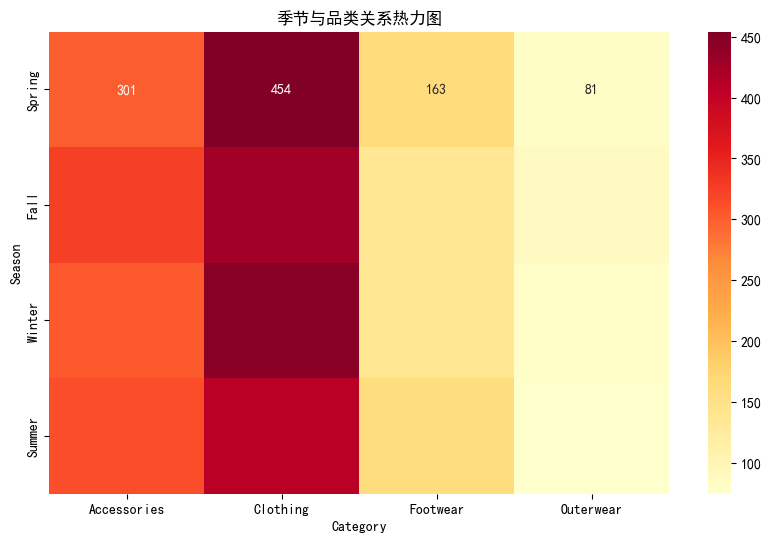

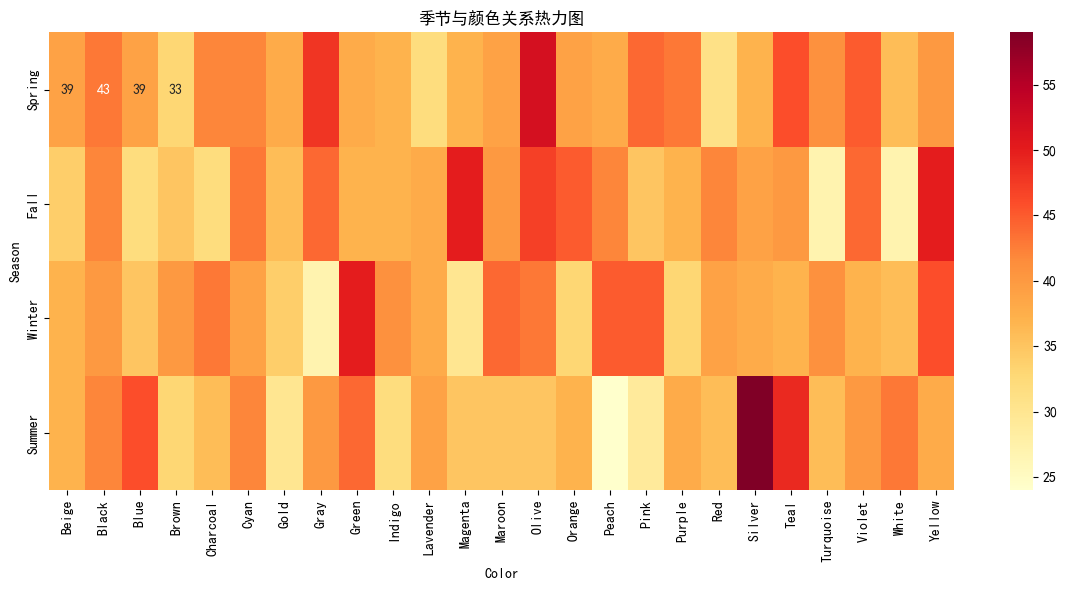

In [29]:

# 季节与品类的关系分析
season_category = pd.crosstab(data['Season'], data['Category'])
season_category = season_category.reindex(season_counts_sorted.index)

# 绘制热力图展示季节与品类的关系
plt.figure(figsize=(10, 6))
sns.heatmap(season_category, annot=True, fmt='d', cmap='YlOrRd')
plt.title('季节与品类关系热力图')

# 季节与颜色的关系分析
season_color = pd.crosstab(data['Season'], data['Color'])
season_color = season_color.reindex(season_counts_sorted.index)

# 绘制热力图展示季节与颜色的关系
plt.figure(figsize=(12, 6))
sns.heatmap(season_color, annot=True, fmt='d', cmap='YlOrRd')
plt.title('季节与颜色关系热力图')

plt.tight_layout()
plt.show()

### 综合分析与建议

In [30]:

print("产品与品类综合分析")
print("=" * 150)

# 1. 主要发现 - 品类
top_category = category_counts.index[0]
print(f"1. 最受欢迎的品类: {top_category}, 占总购买次数的{category_counts[top_category]/len(data)*100:.1f}%")

top_sales_category = category_sales.index[0]
print(f"2. 销售额最高的品类: {top_sales_category}, 占总销售额的{category_share[top_sales_category]}%")

# 2. 主要发现 - 颜色
top_color = color_counts.index[0]
print(f"3. 最受欢迎的颜色: {top_color}, 购买次数{color_counts[top_color]}")

top_sales_color = color_avg_sales.index[0]
print(f"4. 平均销售额最高的颜色: {top_sales_color}, 平均${color_avg_sales[top_sales_color]:.2f}")

# 3. 主要发现 - 季节
top_season = season_counts.sort_values(ascending=False).index[0]
print(f"5. 购买次数最多的季节: {top_season}, 购买次数{season_counts[top_season]}")

top_sales_season = season_sales.sort_values(ascending=False).index[0]
print(f"6. 销售额最高的季节: {top_sales_season}, 总销售额${season_sales[top_sales_season]:.2f}")

# 提出营销建议
print("\n营销建议:")
print("1. 品类策略:")
print(f"   - 重点推广{top_category}品类，保持市场领先地位")
print(f"   - 开发{category_sales.index[-1]}品类的高端产品，提高平均销售额")

print("\n2. 颜色策略:")
print(f"   - 增加{top_color}颜色的产品库存")
print(f"   - 推广{top_sales_color}颜色的高端产品线")

print("\n3. 季节策略:")
print(f"   - 在{top_season}季节加大营销投入")
print(f"   - 针对{season_sales.sort_values(ascending=False).index[-1]}季节开发特色产品，平衡季节性销售差异")

print("\n4. 交叉销售策略:")
print("   - 根据季节与颜色的关系，推出季节性配色产品")
print("   - 根据品类与颜色的关系，开发品类专属配色")

产品与品类综合分析
1. 最受欢迎的品类: Clothing, 占总购买次数的44.5%
2. 销售额最高的品类: Clothing, 占总销售额的44.73%
3. 最受欢迎的颜色: Olive, 购买次数177
4. 平均销售额最高的颜色: Green, 平均$65.70
5. 购买次数最多的季节: Spring, 购买次数999
6. 销售额最高的季节: Fall, 总销售额$60018.00

营销建议:
1. 品类策略:
   - 重点推广Clothing品类，保持市场领先地位
   - 开发Outerwear品类的高端产品，提高平均销售额

2. 颜色策略:
   - 增加Olive颜色的产品库存
   - 推广Green颜色的高端产品线

3. 季节策略:
   - 在Spring季节加大营销投入
   - 针对Summer季节开发特色产品，平衡季节性销售差异

4. 交叉销售策略:
   - 根据季节与颜色的关系，推出季节性配色产品
   - 根据品类与颜色的关系，开发品类专属配色


## 5.3 购买行为分析

### 5.3.1 购买金额分布

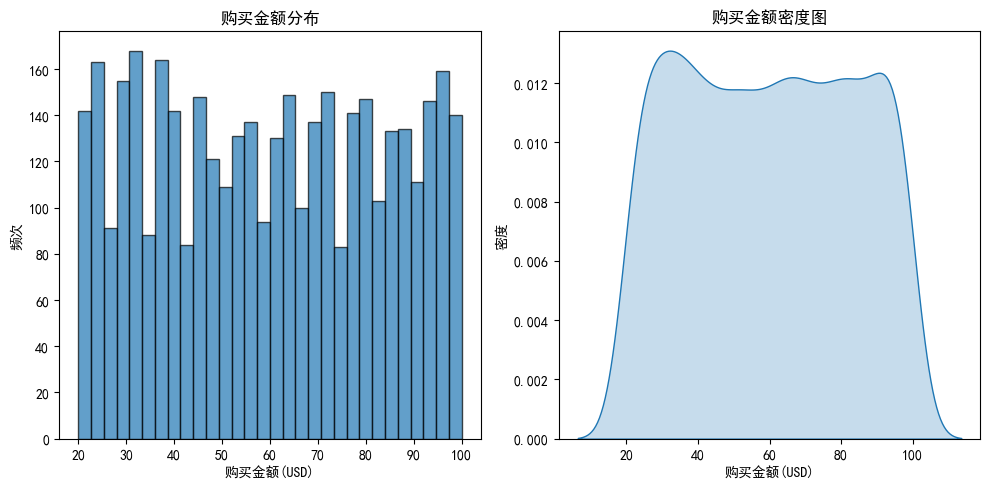

In [31]:

# 绘制购买金额分布图
plt.figure(figsize=(15, 5))

# 子图1: 购买金额直方图
plt.subplot(1, 3, 1)
plt.hist(data['Purchase Amount (USD)'], bins=30, edgecolor='black', alpha=0.7)
plt.title('购买金额分布')
plt.xlabel('购买金额(USD)')
plt.ylabel('频次')

# 子图2: 购买金额密度图
plt.subplot(1, 3, 2)
sns.kdeplot(data['Purchase Amount (USD)'], fill=True)
plt.title('购买金额密度图')
plt.xlabel('购买金额(USD)')
plt.ylabel('密度')

plt.tight_layout()
plt.show()

## 5.3.2 折扣使用情况与购买金额的关系

In [32]:

# 折扣使用基本情况
discount_counts = data['Discount Applied'].value_counts()
print("折扣使用情况:")
print(discount_counts)

# 折扣使用率
discount_rate = discount_counts['Yes'] / len(data) * 100
print(f"\n折扣使用率: {discount_rate:.2f}%")

折扣使用情况:
Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

折扣使用率: 43.00%


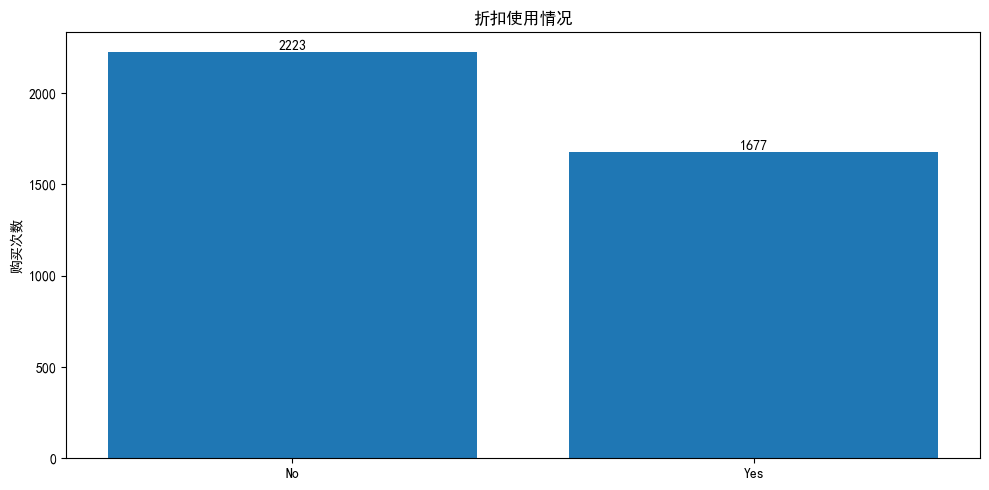

In [33]:

# 可视化
plt.figure(figsize=(10, 5))

plt.bar(discount_counts.index, discount_counts.values)
plt.title('折扣使用情况')
plt.ylabel('购买次数')

# 在柱状图上添加数值标签
for i, v in enumerate(discount_counts.values):
    plt.text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()

In [49]:

# 折扣对购买金额的影响
discount_purchase = data.groupby('Discount Applied')['Purchase Amount (USD)'].agg(['mean', 'median', 'std', 'count']).round(2)
discount_purchase.columns = ['平均金额', '中位数', '标准差', '购买次数']
print("\n折扣对购买金额的影响:")
print(discount_purchase)


折扣对购买金额的影响:
                   平均金额   中位数    标准差  购买次数
Discount Applied                          
No                60.13  60.0  23.74  2223
Yes               59.28  60.0  23.61  1677


In [35]:

# 折扣与其他因素的关系

# 折扣与品类的关系---各品类折扣使用率(%)
discount_category = pd.crosstab(data['Discount Applied'], data['Category'], normalize='index') * 100
# 折扣与季节的关系---各季节折扣使用率(%)
discount_season = pd.crosstab(data['Discount Applied'], data['Season'], normalize='index') * 100
# 折扣与支付方式的关系---各支付方式折扣使用率(%)
discount_payment = pd.crosstab(data['Discount Applied'], data['Payment Method'], normalize='index') * 100

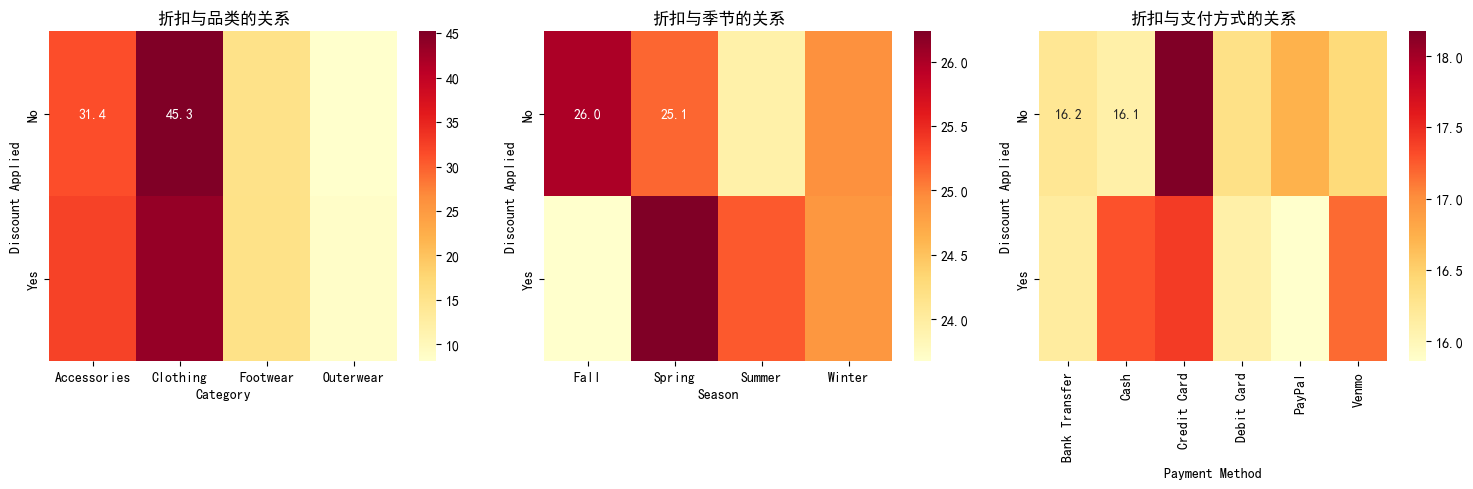

In [36]:

# 绘制上述关系的热力图
plt.figure(figsize=(15, 5))

# 子图1: 折扣与品类的关系
plt.subplot(1, 3, 1)
sns.heatmap(discount_category, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('折扣与品类的关系')
# 子图2: 折扣与季节的关系
plt.subplot(1, 3, 2)
sns.heatmap(discount_season, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('折扣与季节的关系')
# 子图3: 折扣与支付方式的关系
plt.subplot(1, 3, 3)
sns.heatmap(discount_payment, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('折扣与支付方式的关系')

plt.tight_layout()
plt.show()

### 5.3.3 促销码使用率及其对购买行为的影响

In [37]:

# 促销码使用基本情况
promo_counts = data['Promo Code Used'].value_counts()
print("促销码使用情况:")
print(promo_counts)

# 促销码使用率
promo_rate = promo_counts['Yes'] / len(data) * 100
print(f"\n促销码使用率: {promo_rate:.2f}%")

# 促销码对购买金额的影响
promo_purchase = data.groupby('Promo Code Used')['Purchase Amount (USD)'].agg(['mean', 'median', 'std', 'count']).round(2)
promo_purchase.columns = ['平均金额', '中位数', '标准差', '购买次数']
print("\n促销码对购买金额的影响:")
print(promo_purchase)

促销码使用情况:
Promo Code Used
No     2223
Yes    1677
Name: count, dtype: int64

促销码使用率: 43.00%

促销码对购买金额的影响:
                  平均金额   中位数    标准差  购买次数
Promo Code Used                          
No               60.13  60.0  23.74  2223
Yes              59.28  60.0  23.61  1677


In [38]:

# 促销码与折扣的关系
promo_discount = pd.crosstab(data['Promo Code Used'], data['Discount Applied'], normalize='index') * 100
print("\n促销码与折扣的关系(%):")
print(promo_discount.round(2))


促销码与折扣的关系(%):
Discount Applied     No    Yes
Promo Code Used               
No                100.0    0.0
Yes                 0.0  100.0


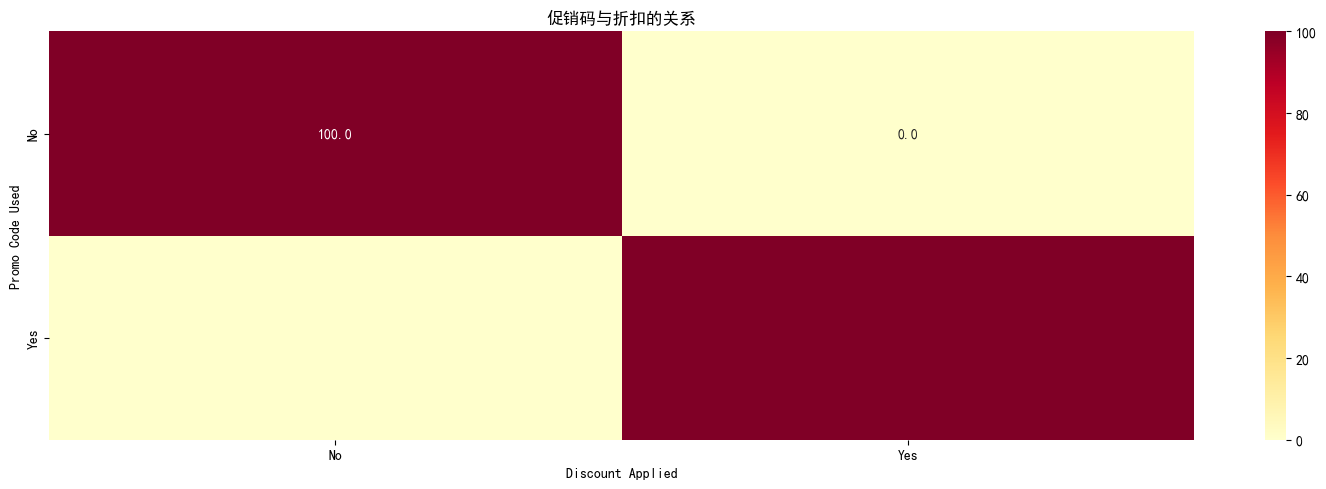

In [39]:

# 促销码与折扣的关系热力图
plt.figure(figsize=(15, 5))

sns.heatmap(promo_discount, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('促销码与折扣的关系')

plt.tight_layout()
plt.show()

### 5.3.4 订阅用户 vs 非订阅用户的消费差异

In [40]:

# 订阅用户基本情况
subscription_counts = data['Subscription Status'].value_counts()
print("订阅用户情况:")
print(subscription_counts)

# 订阅率
subscription_rate = subscription_counts['Yes'] / len(data) * 100
print(f"\n订阅率: {subscription_rate:.2f}%")

# 订阅用户与非订阅用户的消费差异
subscription_purchase = data.groupby('Subscription Status')['Purchase Amount (USD)'].agg(['mean', 'median', 'std', 'count']).round(2)
subscription_purchase.columns = ['平均金额', '中位数', '标准差', '购买次数']
print("\n订阅用户与非订阅用户的消费差异:")
print(subscription_purchase)

订阅用户情况:
Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

订阅率: 27.00%

订阅用户与非订阅用户的消费差异:
                      平均金额   中位数    标准差  购买次数
Subscription Status                          
No                   59.87  60.0  23.78  2847
Yes                  59.49  60.0  23.45  1053


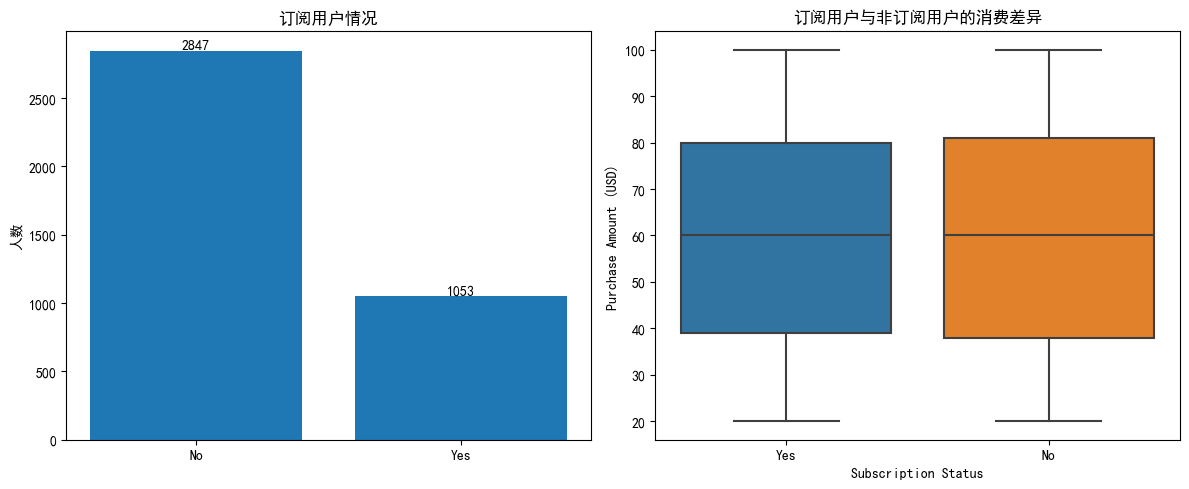

In [41]:

# 订阅用户与非订阅用户的消费差异可视化
plt.figure(figsize=(12, 5))

# 子图1: 订阅用户情况
plt.subplot(1, 2, 1)
plt.bar(subscription_counts.index, subscription_counts.values)
plt.title('订阅用户情况')
plt.ylabel('人数')

# 在柱状图上添加数值标签
for i, v in enumerate(subscription_counts.values):
    plt.text(i, v + 10, str(v), ha='center')

# 子图2: 订阅用户与非订阅用户的消费差异
plt.subplot(1, 2, 2)
sns.boxplot(x='Subscription Status', y='Purchase Amount (USD)', data=data)
plt.title('订阅用户与非订阅用户的消费差异')
    
plt.tight_layout()
plt.show()

In [42]:

# 订阅用户与其他因素的关系

# 订阅用户与购买频率的关系
subscription_frequency = pd.crosstab(data['Subscription Status'], data['Frequency of Purchases'], normalize='index') * 100
# 订阅用户与支付方式的关系
subscription_payment = pd.crosstab(data['Subscription Status'], data['Payment Method'], normalize='index') * 100
# 订阅用户与折扣/促销码使用的关系
subscription_discount = pd.crosstab(data['Subscription Status'], data['Discount Applied'], normalize='index') * 100

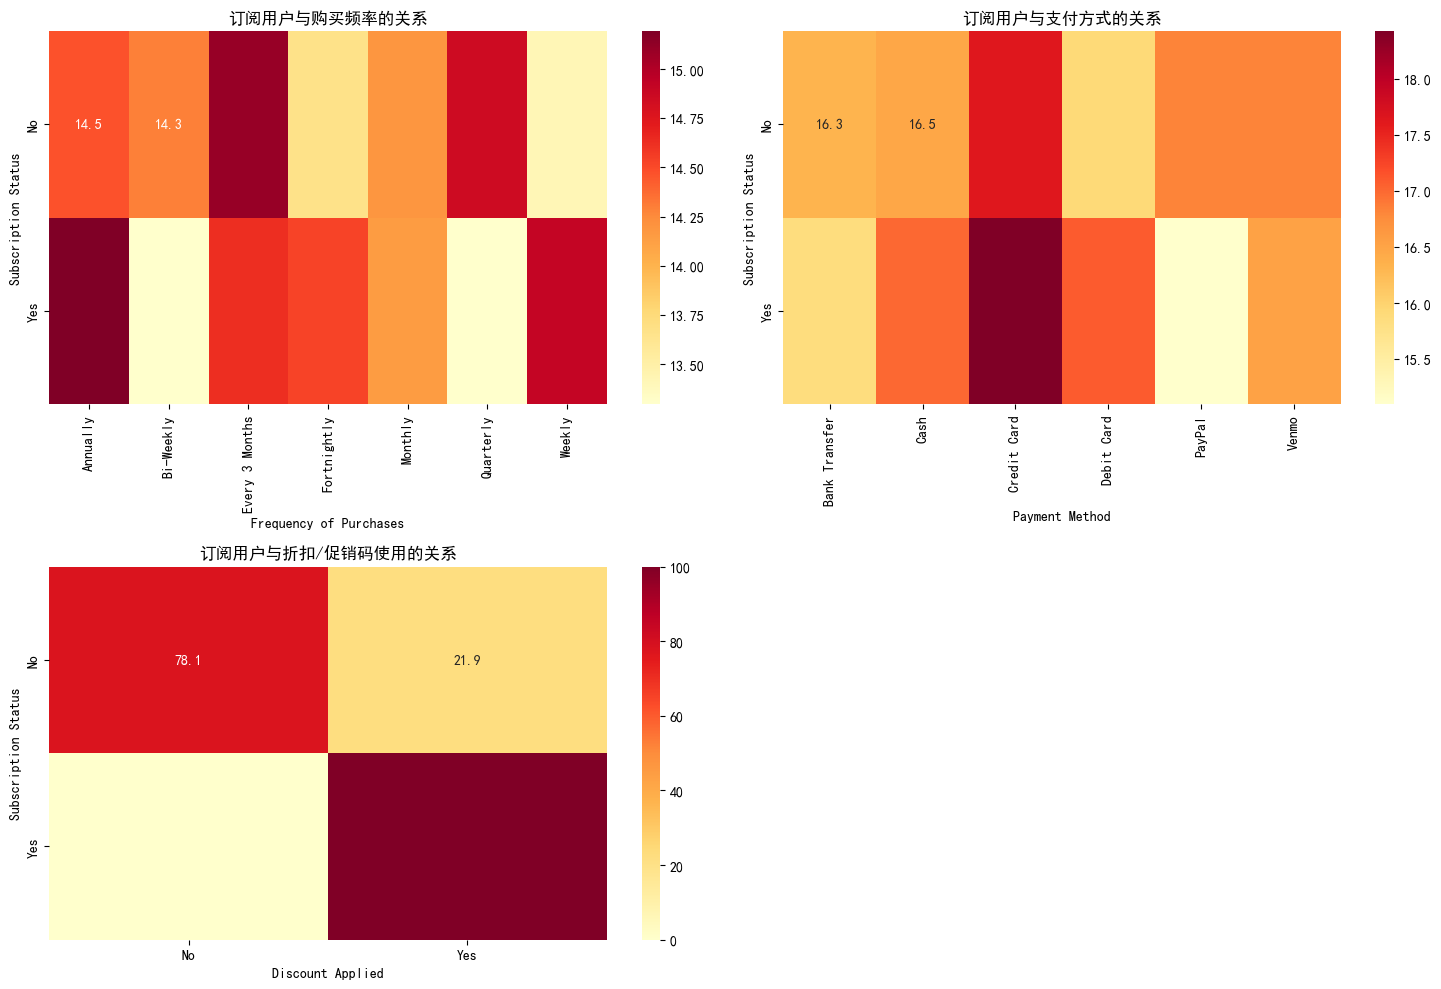

In [43]:

# 绘制订阅用户与其他因素的关系热力图
plt.figure(figsize=(15, 10))

# 子图1: 订阅用户与购买频率的关系
plt.subplot(2, 2, 1)
sns.heatmap(subscription_frequency, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('订阅用户与购买频率的关系')

# 子图2: 订阅用户与支付方式的关系
plt.subplot(2, 2, 2)
sns.heatmap(subscription_payment, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('订阅用户与支付方式的关系')

# 子图3: 订阅用户与折扣/促销码使用的关系
plt.subplot(2, 2, 3)
sns.heatmap(subscription_discount, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('订阅用户与折扣/促销码使用的关系')

plt.tight_layout()
plt.show()

In [47]:

# 订阅用户的复购率分析
print("\n订阅用户的复购率分析:")
subscription_repurchase = data.groupby('Subscription Status')['Previous Purchases'].mean().round(2)
print("平均历史购买次数:")
print(subscription_repurchase)




订阅用户的复购率分析:
平均历史购买次数:
Subscription Status
No     25.08
Yes    26.08
Name: Previous Purchases, dtype: float64


### 综合分析与建议

In [50]:

print("购买行为综合分析")
print("=" * 150)

# 1. 主要发现 - 购买金额
mean_purchase = data['Purchase Amount (USD)'].mean()
median_purchase = data['Purchase Amount (USD)'].median()
print(f"1. 平均购买金额: ${mean_purchase:.2f}, 中位数: ${median_purchase:.2f}")

# 2. 主要发现 - 折扣
discount_effect = discount_purchase.loc['Yes', '平均金额'] - discount_purchase.loc['No', '平均金额']
print(f"2. 折扣/促销码对购买金额的影响: 使用折扣/促销码的订单平均金额{'高' if discount_effect > 0 else '低'}${abs(discount_effect):.2f}")

# 3. 主要发现 - 订阅用户
subscription_effect = subscription_purchase.loc['Yes', '平均金额'] - subscription_purchase.loc['No', '平均金额']
print(f"3. 订阅用户的消费差异: 订阅用户平均消费金额{'高' if subscription_effect > 0 else '低'}${abs(subscription_effect):.2f}")

# 提出营销建议
print("\n营销建议:")
print("1. 定价策略:")
print(f"   - 基于平均购买金额${mean_purchase:.2f}和中位数${median_purchase:.2f}制定价格区间")
print("   - 考虑设置价格锚点，引导消费者选择更高价位的商品")

print("\n2. 折扣/促销码策略:")
if discount_effect > 0:
    print("   - 折扣策略有效，可继续推广折扣活动以提升销售额"
          "   - 促销码策略有效，可增加促销码的发放和推广")
else:
    print("   - 折扣策略可能需要调整，考虑优化折扣力度或条件\n"
          "   - 促销码策略可能需要优化，考虑调整促销码的面值或使用条件")

print("\n3. 订阅用户策略:")
print(f"   - 订阅用户占比{subscription_rate:.2f}%，有提升空间")
if subscription_effect > 0:
    print("   - 订阅用户消费更高，应加大订阅服务的推广力度")
    print("   - 为订阅用户提供专属优惠，提高用户粘性")
else:
    print("   - 需要优化订阅服务的价值主张，提高订阅用户的消费意愿")

print("\n4. 交叉营销策略:")
print("   - 优化折扣和促销码的结合使用模式，设计更好的组合营销活动")
print("   - 针对高价值用户群体，提供个性化折扣和促销码")
print("   - 利用订阅用户的数据，优化产品推荐和营销信息")

购买行为综合分析
1. 平均购买金额: $59.76, 中位数: $60.00
2. 折扣/促销码对购买金额的影响: 使用折扣/促销码的订单平均金额低$0.85
3. 订阅用户的消费差异: 订阅用户平均消费金额低$0.38

营销建议:
1. 定价策略:
   - 基于平均购买金额$59.76和中位数$60.00制定价格区间
   - 考虑设置价格锚点，引导消费者选择更高价位的商品

2. 折扣/促销码策略:
   - 折扣策略可能需要调整，考虑优化折扣力度或条件
   - 促销码策略可能需要优化，考虑调整促销码的面值或使用条件

3. 订阅用户策略:
   - 订阅用户占比27.00%，有提升空间
   - 需要优化订阅服务的价值主张，提高订阅用户的消费意愿

4. 交叉营销策略:
   - 优化折扣和促销码的结合使用模式，设计更好的组合营销活动
   - 针对高价值用户群体，提供个性化折扣和促销码
   - 利用订阅用户的数据，优化产品推荐和营销信息


## 5.4 支付与配送偏好分析

### 5.4.1 最常用的支付方式

In [54]:

# 支付方式基本情况
payment_counts = data['Payment Method'].value_counts()
payment_percentage = (payment_counts / len(data) * 100).round(2)

print("支付方式使用情况:")
payment_summary = pd.DataFrame({
    '使用次数': payment_counts,
    '占比(%)': payment_percentage
})
print(payment_summary)

支付方式使用情况:
                使用次数  占比(%)
Payment Method             
Credit Card      696  17.85
Venmo            653  16.74
Cash             648  16.62
PayPal           638  16.36
Debit Card       633  16.23
Bank Transfer    632  16.21


In [55]:

# 支付方式与购买金额的关系
payment_purchase = data.groupby('Payment Method')['Purchase Amount (USD)'].agg([
    'mean', 'median', 'std', 'count'
]).round(2)
payment_purchase.columns = ['平均金额', '中位数', '标准差', '使用次数']

print("\n各支付方式的购买金额分析:")
print(payment_purchase)


各支付方式的购买金额分析:
                 平均金额   中位数    标准差  使用次数
Payment Method                          
Bank Transfer   58.74  59.0  24.00   632
Cash            59.93  61.0  23.72   648
Credit Card     61.16  62.5  23.70   696
Debit Card      58.64  57.0  23.44   633
PayPal          58.70  59.0  23.19   638
Venmo           61.24  62.0  23.97   653


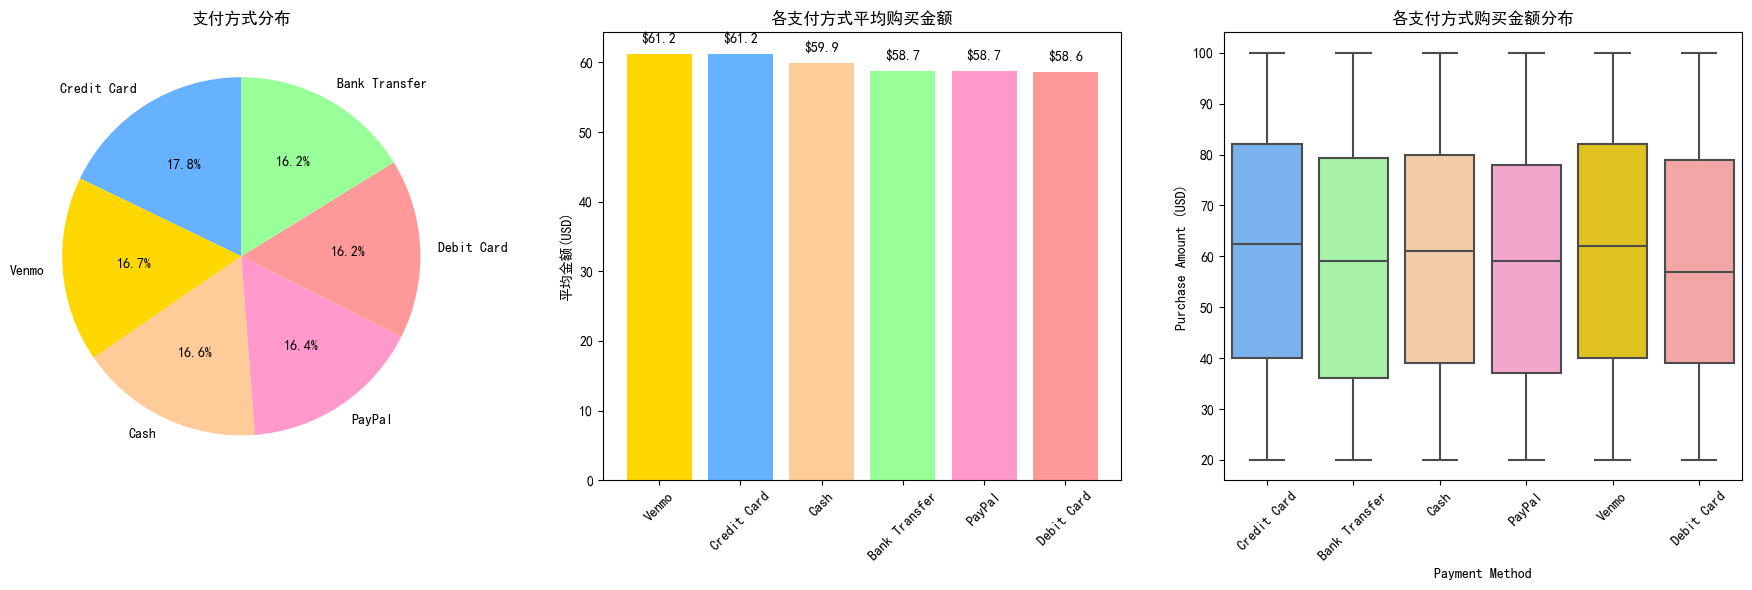

In [56]:

# 定义6种颜色，并为每个支付方式指定固定颜色
payment_colors = {
    'Debit Card': '#FF9999',
    'Credit Card': '#66B2FF',
    'Bank Transfer': '#99FF99',
    'Cash': '#FFCC99',
    'PayPal': '#FF99CC',
    'Venmo': '#FFD700' 
}

# 可视化
plt.figure(figsize=(18, 6))

# 子图1: 支付方式使用次数
plt.subplot(1, 3, 1)
# 确保饼图颜色与支付方式对应
pie_colors = [payment_colors[method] for method in payment_counts.index]
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=pie_colors)
plt.title('支付方式分布')

# 子图2: 各支付方式平均购买金额（按降序排序）
plt.subplot(1, 3, 2)
payment_purchase_sorted = payment_purchase.sort_values('平均金额', ascending=False)
# 为每个支付方式使用固定颜色
bar_colors = [payment_colors[method] for method in payment_purchase_sorted.index]
plt.bar(payment_purchase_sorted.index, payment_purchase_sorted['平均金额'], color=bar_colors)
plt.title('各支付方式平均购买金额')
plt.ylabel('平均金额(USD)')
plt.xticks(rotation=45)

# 在柱状图上添加数值标签（使用排序后的数据）
for i, v in enumerate(payment_purchase_sorted['平均金额']):
    plt.text(i, v + max(payment_purchase_sorted['平均金额'])*0.02,
             f'${v:.1f}', ha='center', va='bottom')

# 子图3: 支付方式箱线图
plt.subplot(1, 3, 3)
# 为箱线图使用固定颜色
sns.boxplot(x='Payment Method', y='Purchase Amount (USD)', 
            data=data, palette=payment_colors)
plt.title('各支付方式购买金额分布')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [57]:

# 支付方式与其他因素的关系分析

# 支付方式与购买频率的关系
payment_frequency = pd.crosstab(data['Payment Method'], data['Frequency of Purchases'], 
                               normalize='index') * 100
# 支付方式与折扣使用的关系
payment_discount = pd.crosstab(data['Payment Method'], data['Discount Applied'], 
                              normalize='index') * 100
# 支付方式与订阅状态的关系
payment_subscription = pd.crosstab(data['Payment Method'], data['Subscription Status'], 
                                  normalize='index') * 100

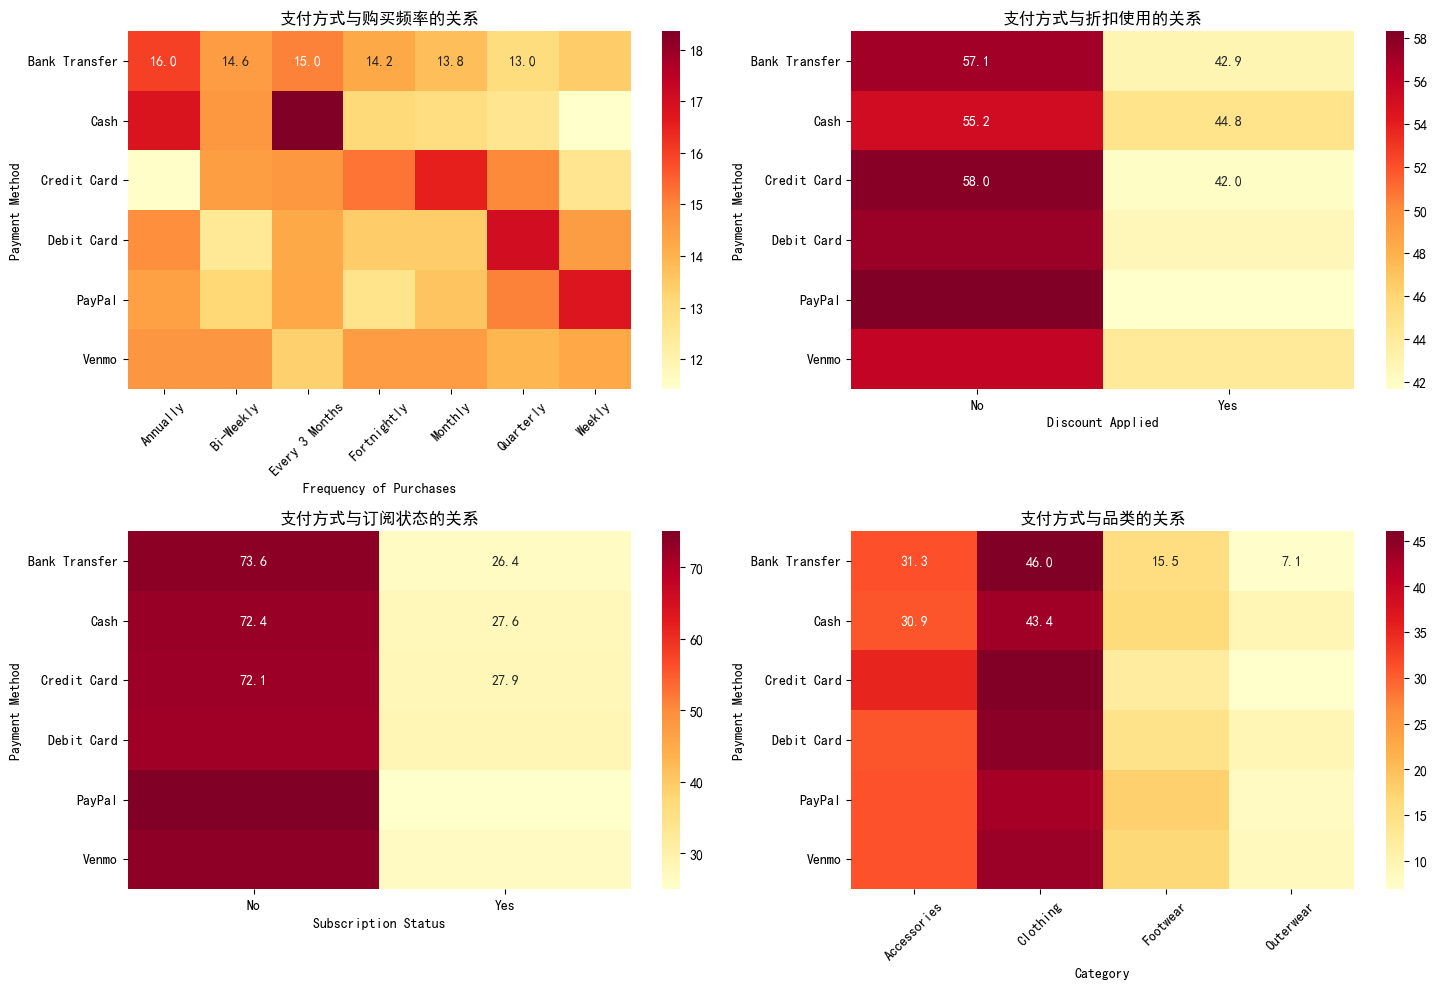

In [58]:

# 绘制支付方式与其他因素的关系热力图
plt.figure(figsize=(15, 10))

# 子图1: 支付方式与购买频率的关系
plt.subplot(2, 2, 1)
sns.heatmap(payment_frequency, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('支付方式与购买频率的关系')
plt.xticks(rotation=45)

# 子图2: 支付方式与折扣使用的关系
plt.subplot(2, 2, 2)
sns.heatmap(payment_discount, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('支付方式与折扣使用的关系')

# 子图3: 支付方式与订阅状态的关系
plt.subplot(2, 2, 3)
sns.heatmap(payment_subscription, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('支付方式与订阅状态的关系')

# 子图4: 支付方式与品类的关系
payment_category = pd.crosstab(data['Payment Method'], data['Category'], normalize='index') * 100
plt.subplot(2, 2, 4)
sns.heatmap(payment_category, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('支付方式与品类的关系')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 5.4.2 配送方式偏好

In [59]:

# 配送方式基本情况
shipping_counts = data['Shipping Type'].value_counts()
shipping_percentage = (shipping_counts / len(data) * 100).round(2)

print("配送方式使用情况:")
shipping_summary = pd.DataFrame({
    '使用次数': shipping_counts,
    '占比(%)': shipping_percentage
})
print(shipping_summary)

配送方式使用情况:
                使用次数  占比(%)
Shipping Type              
Free Shipping    675  17.31
Standard         654  16.77
Store Pickup     650  16.67
Next Day Air     648  16.62
Express          646  16.56
2-Day Shipping   627  16.08


In [60]:

# 配送方式与购买金额的关系
shipping_purchase = data.groupby('Shipping Type')['Purchase Amount (USD)'].agg([
    'mean', 'median', 'std', 'count'
]).round(2)
shipping_purchase.columns = ['平均金额', '中位数', '标准差', '使用次数']

print("\n各配送方式的购买金额分析:")
print(shipping_purchase)


各配送方式的购买金额分析:
                 平均金额   中位数    标准差  使用次数
Shipping Type                           
2-Day Shipping  60.73  60.0  23.37   627
Express         60.48  60.0  24.01   646
Free Shipping   60.41  62.0  23.40   675
Next Day Air    58.63  58.5  23.30   648
Standard        58.46  58.0  24.08   654
Store Pickup    59.89  60.0  23.92   650


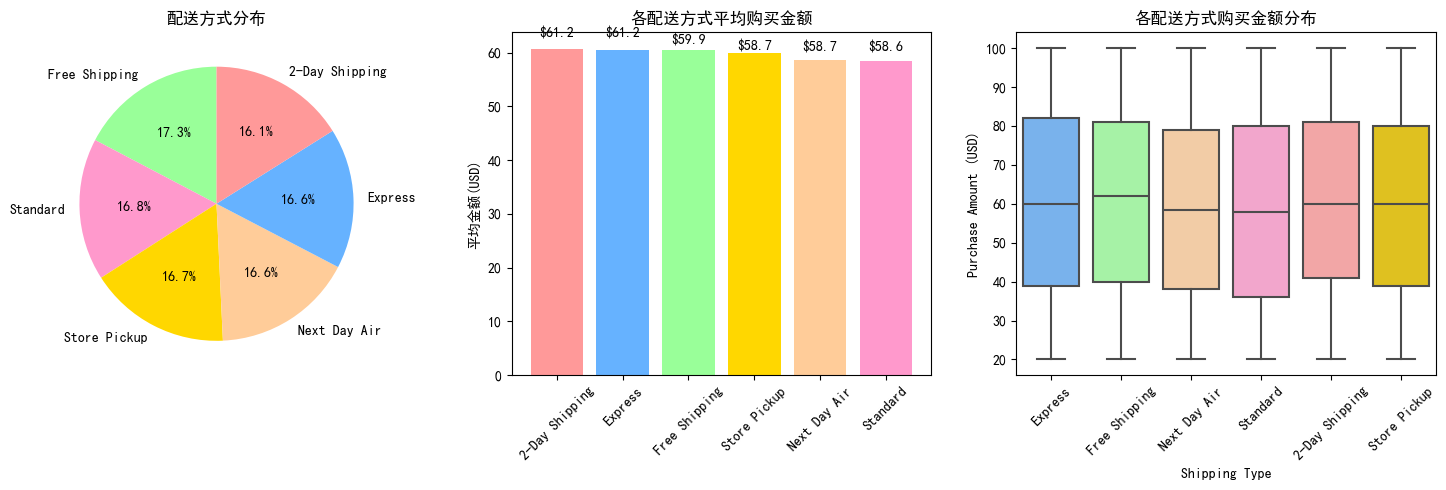

In [61]:

# 定义6种颜色，并为每个配送方式指定固定颜色
shipping_colors = {
    '2-Day Shipping': '#FF9999',
    'Express': '#66B2FF',
    'Free Shipping': '#99FF99',
    'Next Day Air': '#FFCC99',
    'Standard': '#FF99CC',
    'Store Pickup': '#FFD700'
}

# 配送方式可视化
plt.figure(figsize=(15, 5))

# 子图1: 配送方式使用次数
plt.subplot(1, 3, 1)
# 确保饼图颜色与支付方式对应
pie_colors = [shipping_colors[method] for method in shipping_counts.index]
plt.pie(shipping_counts.values, labels=shipping_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=pie_colors)
plt.title('配送方式分布')

# 子图2: 各配送方式平均购买金额（按降序排序）
plt.subplot(1, 3, 2)
shipping_purchase_sorted = shipping_purchase.sort_values('平均金额', ascending=False)
# 为每个配送方式使用固定颜色
bar_colors = [shipping_colors[method] for method in shipping_purchase_sorted.index]
plt.bar(shipping_purchase_sorted.index, shipping_purchase_sorted['平均金额'], color=bar_colors)
plt.title('各配送方式平均购买金额')
plt.ylabel('平均金额(USD)')
plt.xticks(rotation=45)

#plt.bar(payment_purchase_sorted.index, payment_purchase_sorted['平均金额'], color=bar_colors)

# 在柱状图上添加数值标签（使用排序后的数据）
for i, v in enumerate(payment_purchase_sorted['平均金额']):
    plt.text(i, v + max(payment_purchase_sorted['平均金额'])*0.02,
             f'${v:.1f}', ha='center', va='bottom')
    
# 子图3: 配送方式箱线图
plt.subplot(1, 3, 3)
# 为箱线图使用固定颜色
sns.boxplot(x='Shipping Type', y='Purchase Amount (USD)', data=data, palette=shipping_colors)
plt.title('各配送方式购买金额分布')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [62]:

# 配送方式与购买频率的关系
shipping_frequency = pd.crosstab(data['Shipping Type'], data['Frequency of Purchases'], 
                                normalize='index') * 100
# 配送方式与地区的关系（前5地区）
top_locations = data['Location'].value_counts().head(5).index
shipping_location = pd.crosstab(data[data['Location'].isin(top_locations)]['Shipping Type'], 
                               data[data['Location'].isin(top_locations)]['Location'],
                               normalize='index') * 100
# 配送方式与支付方式的关系
shipping_payment = pd.crosstab(data['Shipping Type'], data['Payment Method'], 
                              normalize='index') * 100

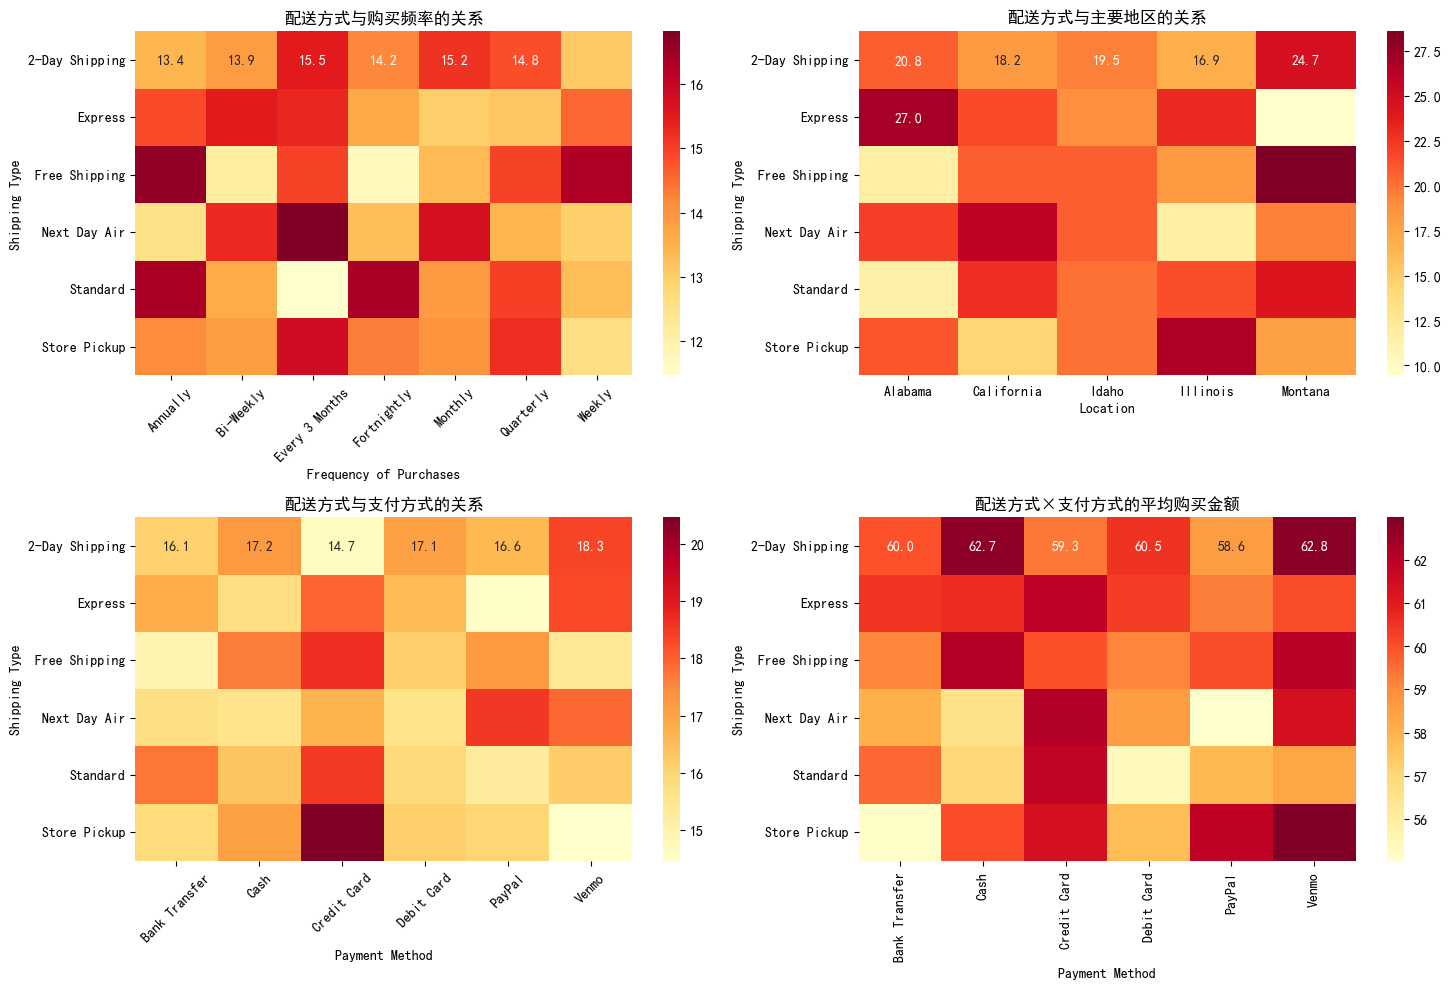

In [63]:

# 绘制配送方式与其他因素的关系热力图
plt.figure(figsize=(15, 10))

# 子图1: 配送方式与购买频率的关系
plt.subplot(2, 2, 1)
sns.heatmap(shipping_frequency, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('配送方式与购买频率的关系')
plt.xticks(rotation=45)


# 子图2: 配送方式与地区的关系
plt.subplot(2, 2, 2)
sns.heatmap(shipping_location, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('配送方式与主要地区的关系')

# 子图3: 配送方式与支付方式的关系
plt.subplot(2, 2, 3)
sns.heatmap(shipping_payment, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('配送方式与支付方式的关系')
plt.xticks(rotation=45)

# 子图4：配送方式、支付方式与平均购买金额的关系
plt.subplot(2, 2, 4)
shipping_payment_avg = data.groupby(['Shipping Type', 'Payment Method'])['Purchase Amount (USD)'].mean().unstack().round(2)
sns.heatmap(shipping_payment_avg, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('配送方式×支付方式的平均购买金额')

plt.tight_layout()
plt.show()

### 5.4.3 配送方式Express的选择影响因素

In [64]:

# 高级分析：配送方式选择的影响因素
print("\n配送方式选择的影响因素分析:")
print("-" * 40)

# 逻辑回归分析（简化版） - 预测选择Express配送的概率
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# 准备数据
df_analysis = data.copy()

# 编码分类变量
le = LabelEncoder()
categorical_cols = ['Payment Method', 'Frequency of Purchases', 'Category', 'Season']
for col in categorical_cols:
    df_analysis[col] = le.fit_transform(df_analysis[col])

# 创建目标变量：是否选择Express配送
df_analysis['Is_Express'] = (df_analysis['Shipping Type'] == 'Express').astype(int)

# 选择特征
features = ['Purchase Amount (USD)', 'Payment Method', 'Frequency of Purchases', 
            'Category', 'Previous Purchases']
X = df_analysis[features]
y = df_analysis['Is_Express']

# 训练模型
model = LogisticRegression()
model.fit(X, y)

# 输出特征重要性
feature_importance = pd.DataFrame({
    '特征': features,
    '系数': model.coef_[0]
}).sort_values('系数', ascending=False)

print("影响选择Express配送的因素（系数越大，影响越正向）:")
print(feature_importance)


配送方式选择的影响因素分析:
----------------------------------------
影响选择Express配送的因素（系数越大，影响越正向）:
                       特征        系数
3                Category  0.014611
1          Payment Method  0.003431
0   Purchase Amount (USD)  0.001495
4      Previous Purchases  0.000915
2  Frequency of Purchases -0.016299


In [65]:

print("支付与配送偏好综合分析")
print("=" * 150)

# 1. 主要发现 - 支付方式
top_payment = payment_counts.index[0]
top_payment_share = payment_percentage.iloc[0]
print(f"1. 最常用的支付方式: {top_payment}, 占比{top_payment_share}%")

highest_avg_payment = payment_purchase['平均金额'].idxmax()
highest_avg_amount = payment_purchase['平均金额'].max()
print(f"2. 平均购买金额最高的支付方式: {highest_avg_payment}, 平均${highest_avg_amount:.2f}")

# 2. 主要发现 - 配送方式
top_shipping = shipping_counts.index[0]
top_shipping_share = shipping_percentage.iloc[0]
print(f"3. 最常用的配送方式: {top_shipping}, 占比{top_shipping_share}%")

highest_avg_shipping = shipping_purchase['平均金额'].idxmax()
highest_avg_shipping_amount = shipping_purchase['平均金额'].max()
print(f"4. 平均购买金额最高的配送方式: {highest_avg_shipping}, 平均${highest_avg_shipping_amount:.2f}")

# 提出营销建议
print("\n营销建议:")
print("1. 支付方式优化:")
print(f"   - 优化{top_payment}支付体验，保持市场主导地位")
print(f"   - 推广{highest_avg_payment}支付方式，提升客单价")
print("   - 为不同支付方式设计差异化营销策略")

print("\n2. 配送策略:")
print(f"   - 保持{top_shipping}配送的服务质量")
print(f"   - 推广{highest_avg_shipping}配送方式，提供增值服务")
print("   - 根据订单金额自动推荐最优配送方式")

print("\n3. 交叉销售策略:")
print("   - 将高价值支付方式与快速配送方式捆绑推广")
print("   - 为高频购买客户提供配送优惠")
print("   - 根据客户历史偏好推荐支付和配送组合")

print("\n4. 个性化推荐:")
print("   - 基于客户特征推荐最适合的支付方式")
print("   - 根据购买金额和频率智能推荐配送方式")
print("   - 为不同地区客户提供本地化支付配送方案")

print("\n5. 运营效率提升:")
print("   - 分析支付和配送组合的利润率")
print("   - 优化库存布局以支持快速配送")
print("   - 监控支付成功率和配送时效指标")

# 关键指标监控建议
print("\n关键监控指标:")
print(f"   - {top_payment}支付成功率: >99%")
print(f"   - {top_shipping}配送准时率: >95%")
print(f"   - 平均订单价值目标: ${mean_purchase * 1.1:.2f} (+10%)")
print(f"   - {highest_avg_shipping}配送使用率提升目标: {shipping_percentage[highest_avg_shipping] * 1.2:.1f}% (+20%)")

支付与配送偏好综合分析
1. 最常用的支付方式: Credit Card, 占比17.85%
2. 平均购买金额最高的支付方式: Venmo, 平均$61.24
3. 最常用的配送方式: Free Shipping, 占比17.31%
4. 平均购买金额最高的配送方式: 2-Day Shipping, 平均$60.73

营销建议:
1. 支付方式优化:
   - 优化Credit Card支付体验，保持市场主导地位
   - 推广Venmo支付方式，提升客单价
   - 为不同支付方式设计差异化营销策略

2. 配送策略:
   - 保持Free Shipping配送的服务质量
   - 推广2-Day Shipping配送方式，提供增值服务
   - 根据订单金额自动推荐最优配送方式

3. 交叉销售策略:
   - 将高价值支付方式与快速配送方式捆绑推广
   - 为高频购买客户提供配送优惠
   - 根据客户历史偏好推荐支付和配送组合

4. 个性化推荐:
   - 基于客户特征推荐最适合的支付方式
   - 根据购买金额和频率智能推荐配送方式
   - 为不同地区客户提供本地化支付配送方案

5. 运营效率提升:
   - 分析支付和配送组合的利润率
   - 优化库存布局以支持快速配送
   - 监控支付成功率和配送时效指标

关键监控指标:
   - Credit Card支付成功率: >99%
   - Free Shipping配送准时率: >95%
   - 平均订单价值目标: $65.74 (+10%)
   - 2-Day Shipping配送使用率提升目标: 19.3% (+20%)


### 5.5 复购与忠诚度分析

### 5.5.1 历史购买次数分析

In [68]:

# 历史购买次数基本统计
previous_purchases_stats = data['Previous Purchases'].describe()
print("历史购买次数基本统计:")
print(previous_purchases_stats)

历史购买次数基本统计:
count    3900.000000
mean       25.351538
std        14.447125
min         1.000000
25%        13.000000
50%        25.000000
75%        38.000000
max        50.000000
Name: Previous Purchases, dtype: float64


In [69]:
# 由上表可知：最小值min值为1代表着无新客户，故而创建复购分组时无需创建新客户标签。

# 创建复购分组
data['Repurchase Group'] = pd.cut(data['Previous Purchases'], 
                                 bins=[0, 1, 3, 10, 100],
                                 labels=['1次购买', '2-3次购买', '4-10次购买', '10+次购买'])
# 复购分组统计
repurchase_group_counts = data['Repurchase Group'].value_counts().sort_index()
repurchase_group_percentage = (repurchase_group_counts / len(data) * 100).round(2)

print("\n复购分组统计:")
repurchase_summary = pd.DataFrame({
    '客户数量': repurchase_group_counts,
    '占比(%)': repurchase_group_percentage
})
print(repurchase_summary)


复购分组统计:
                  客户数量  占比(%)
Repurchase Group             
1次购买                83   2.13
2-3次购买             163   4.18
4-10次购买            538  13.79
10+次购买            3116  79.90


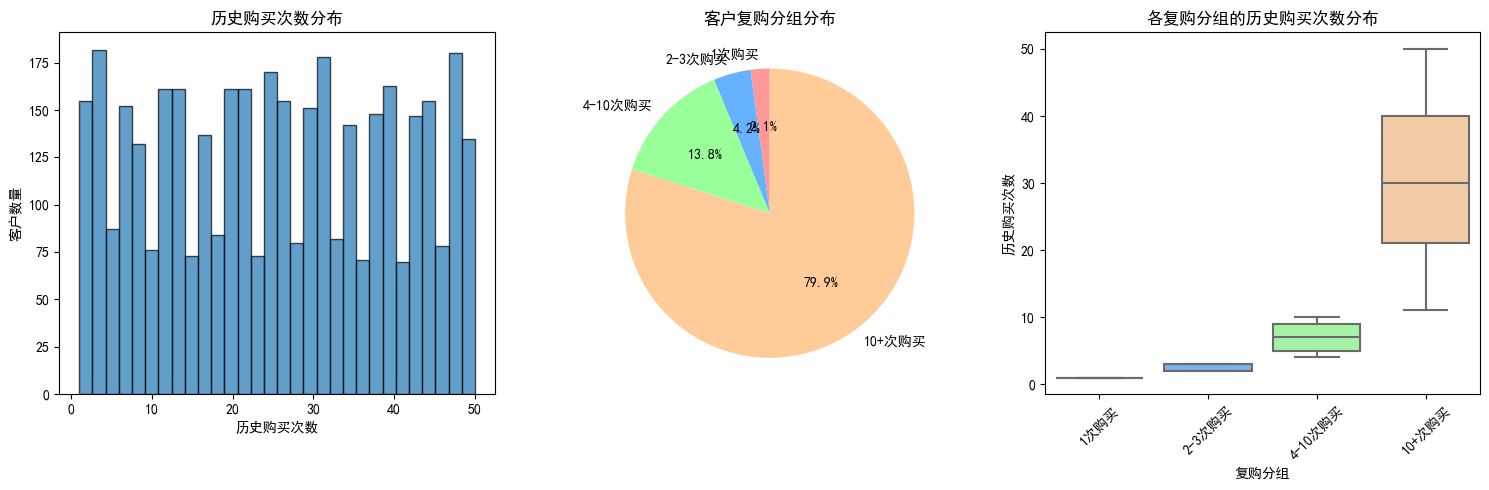

In [70]:

# 历史购买次数分布可视化
plt.figure(figsize=(15, 5))

# 子图1: 历史购买次数直方图
plt.subplot(1, 3, 1)
plt.hist(data['Previous Purchases'], bins=30, edgecolor='black', alpha=0.7)
plt.title('历史购买次数分布')
plt.xlabel('历史购买次数')
plt.ylabel('客户数量')

# 子图2: 复购分组饼图
plt.subplot(1, 3, 2)
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF6B6B']
plt.pie(repurchase_group_counts.values, labels=repurchase_group_counts.index, 
        autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('客户复购分组分布')

# 子图3: 复购分组箱线图
plt.subplot(1, 3, 3)
sns.boxplot(x='Repurchase Group', y='Previous Purchases', data=data, palette=colors)
plt.title('各复购分组的历史购买次数分布')
plt.xlabel('复购分组')
plt.ylabel('历史购买次数')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [71]:

# 复购分组与消费的关系
print("\n复购分组与消费的关系:")
repurchase_behavior = data.groupby('Repurchase Group').agg({
    'Purchase Amount (USD)': ['mean', 'median', 'std'],
    'Age': 'mean',
    'Review Rating': 'mean'
}).round(2)

repurchase_behavior.columns = ['平均消费金额', '消费金额中位数', '消费金额标准差', '平均年龄', '平均评分']
print(repurchase_behavior)


复购分组与消费的关系:
                  平均消费金额  消费金额中位数  消费金额标准差   平均年龄  平均评分
Repurchase Group                                       
1次购买               58.47     58.0    23.67  43.78  3.84
2-3次购买             59.34     58.0    23.46  42.59  3.77
4-10次购买            61.41     63.0    23.85  43.03  3.77
10+次购买             59.54     60.0    23.67  44.33  3.74


### 5.2.2 购买频率分析

In [72]:

# 购买频率基本情况
frequency_counts = data['Frequency of Purchases'].value_counts()
frequency_percentage = (frequency_counts / len(data) * 100).round(2)

print("购买频率分布:")
frequency_summary = pd.DataFrame({
    '客户数量': frequency_counts,
    '占比(%)': frequency_percentage
})
print(frequency_summary)

购买频率分布:
                        客户数量  占比(%)
Frequency of Purchases             
Every 3 Months           584  14.97
Annually                 572  14.67
Quarterly                563  14.44
Monthly                  553  14.18
Bi-Weekly                547  14.03
Fortnightly              542  13.90
Weekly                   539  13.82


In [73]:

# 购买频率与消费的关系
frequency_behavior = data.groupby('Frequency of Purchases').agg({
    'Purchase Amount (USD)': ['mean', 'median', 'std'],
    'Previous Purchases': 'mean',
    'Age': 'mean'
}).round(2)

frequency_behavior.columns = ['平均消费金额', '消费金额中位数', '消费金额标准差', '平均历史购买次数', '平均年龄']
print("\n各购买频率的消费:")
print(frequency_behavior)


各购买频率的消费:
                        平均消费金额  消费金额中位数  消费金额标准差  平均历史购买次数   平均年龄
Frequency of Purchases                                           
Annually                 60.17     59.0    23.97     24.56  44.67
Bi-Weekly                60.69     63.0    23.74     24.79  43.20
Every 3 Months           60.08     60.0    23.99     24.96  43.41
Fortnightly              59.05     58.5    23.86     25.27  43.59
Monthly                  59.33     58.0    23.06     25.28  44.28
Quarterly                59.98     61.0    23.83     26.85  44.69
Weekly                   58.97     58.0    23.38     25.77  44.65


In [74]:

# 购买频率与复购分组的关系
frequency_repurchase = pd.crosstab(data['Frequency of Purchases'], data['Repurchase Group'], 
                                  normalize='index') * 100
print("\n各购买频率的复购分组分布(%):")
print(frequency_repurchase.round(2))


各购买频率的复购分组分布(%):
Repurchase Group        1次购买  2-3次购买  4-10次购买  10+次购买
Frequency of Purchases                               
Annually                1.57    3.67    15.03   79.72
Bi-Weekly               2.19    4.94    12.61   80.26
Every 3 Months          3.08    4.11    14.73   78.08
Fortnightly             2.03    3.69    15.13   79.15
Monthly                 1.81    4.16    13.56   80.47
Quarterly               1.78    4.26    12.79   81.17
Weekly                  2.41    4.45    12.62   80.52


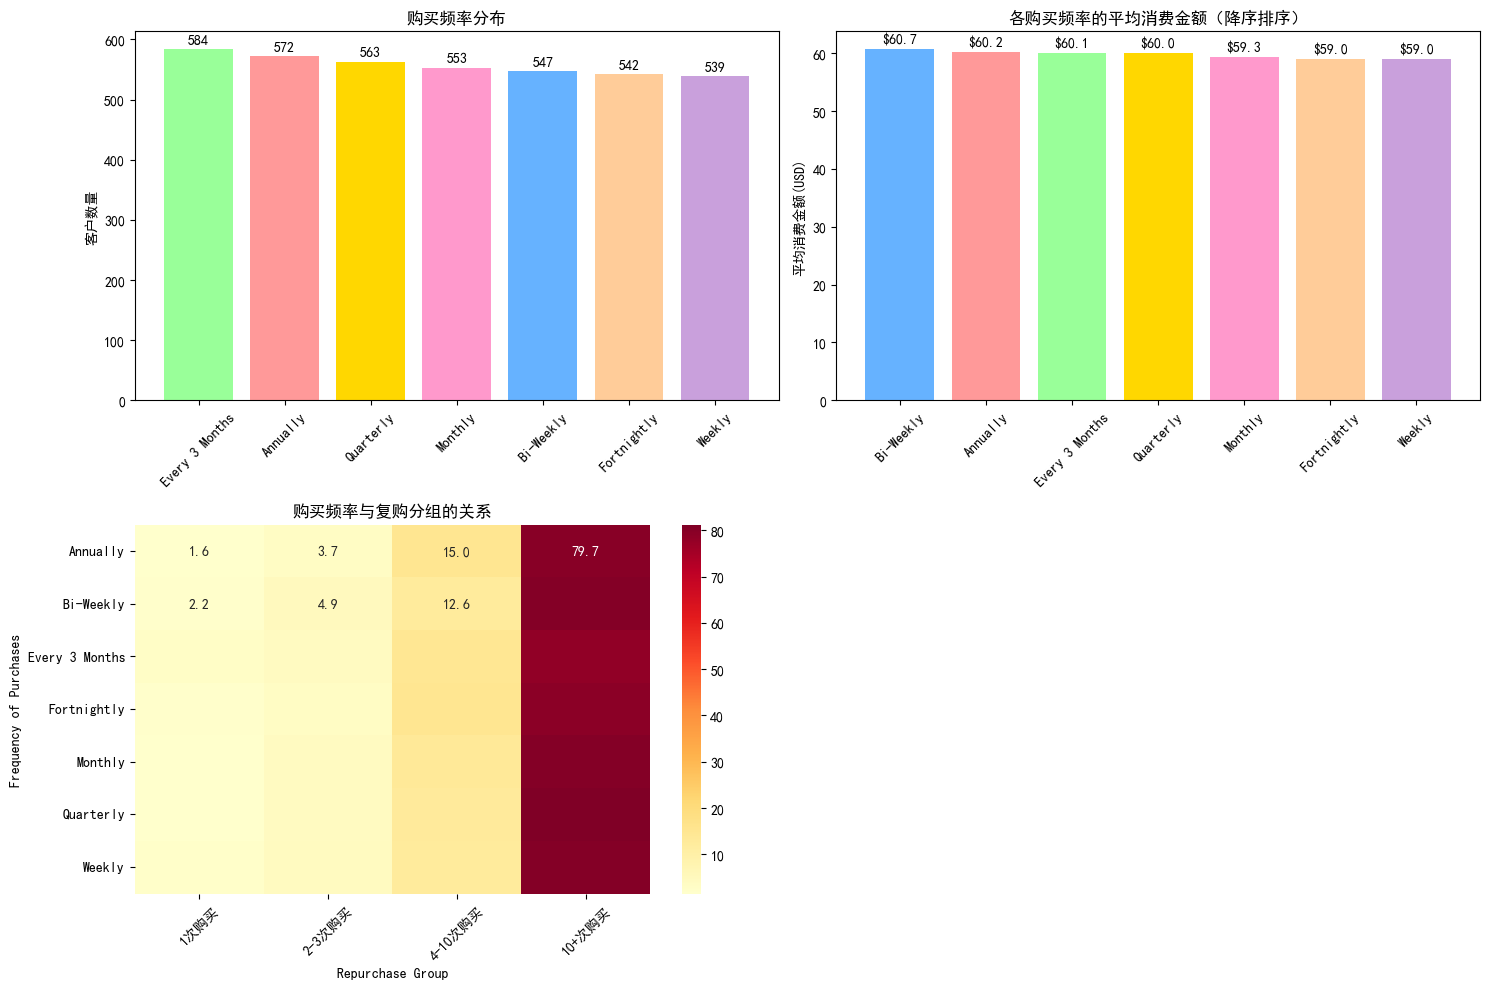

In [75]:

# 定义7种颜色，并为每个购买频率类别指定固定颜色
frequency_color_map = {
    'Annually': '#FF9999',       # 年度
    'Quarterly': '#FFD700',      # 每季度
    'Every 3 Months': '#99FF99', # 每3个月
    'Monthly': '#FF99CC',        # 每月
    'Fortnightly': '#FFCC99',    # 每两周
    'Weekly': '#C9A0DC',         # 每周  
    'Bi-Weekly': '#66B2FF'       # 一周两次
}

# 购买频率分析可视化
plt.figure(figsize=(15, 10))

# 子图1: 购买频率分布
plt.subplot(2, 2, 1)
# 为每个频率类别使用固定颜色
colors1 = [frequency_color_map[group] for group in frequency_counts.index]
plt.bar(frequency_counts.index, frequency_counts.values, color=colors1)
plt.title('购买频率分布')
plt.ylabel('客户数量')
plt.xticks(rotation=45)

# 在柱状图上添加数值标签
for i, v in enumerate(frequency_counts.values):
    plt.text(i, v + max(frequency_counts.values)*0.01, str(v), ha='center', va='bottom')

# 子图2: 购买频率与平均消费金额（按平均消费金额降序排序）
plt.subplot(2, 2, 2)
# 按平均消费金额降序排序
frequency_behavior_sorted = frequency_behavior.sort_values('平均消费金额', ascending=False)
# 为每个频率类别使用固定颜色（注意排序后顺序变化）
colors2 = [frequency_color_map[group] for group in frequency_behavior_sorted.index]
plt.bar(frequency_behavior_sorted.index, frequency_behavior_sorted['平均消费金额'], color=colors2)
plt.title('各购买频率的平均消费金额（降序排序）')
plt.ylabel('平均消费金额(USD)')
plt.xticks(rotation=45)

# 在柱状图上添加数值标签
for i, v in enumerate(frequency_behavior_sorted['平均消费金额']):
    plt.text(i, v + max(frequency_behavior_sorted['平均消费金额'])*0.01, 
             f'${v:.1f}', ha='center', va='bottom')

# 子图3: 购买频率与复购分组的关系热力图
plt.subplot(2, 2, 3)
sns.heatmap(frequency_repurchase, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('购买频率与复购分组的关系')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [76]:

# 各购买频率的的配送方式占比
frequency_shipping = pd.crosstab(data['Frequency of Purchases'], data['Shipping Type'], 
                                normalize='index') * 100

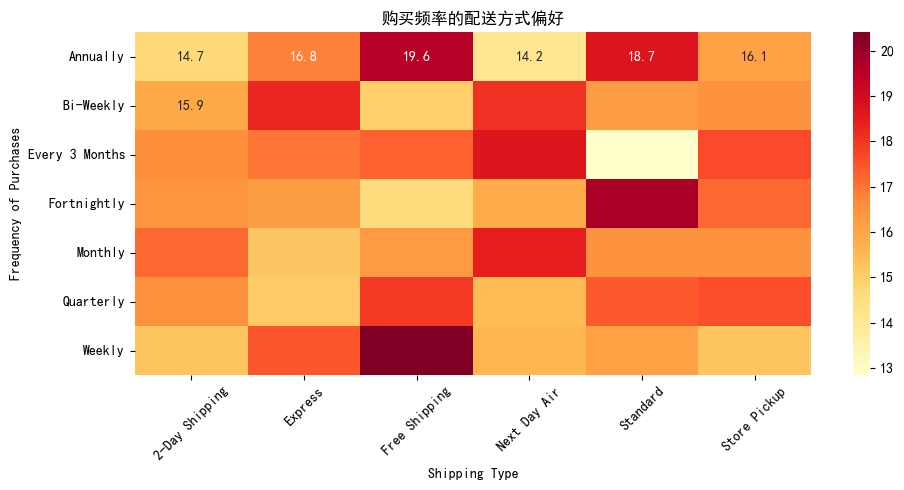

In [77]:

# 购买频率与配送方式的关系热力图
plt.figure(figsize=(10, 5))

sns.heatmap(frequency_shipping, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('购买频率的配送方式偏好')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 5.5.3 高复购用户的特征（年龄，地域，支付方式等）

In [78]:

print("高复购用户特征分析")
print("-" * 50)

# 定义高复购用户：历史购买次数大于等于4次的用户
high_repurchase_threshold = 4
data['High Repurchase'] = data['Previous Purchases'] >= high_repurchase_threshold

high_repurchase_count = data['High Repurchase'].sum()
high_repurchase_percentage = (high_repurchase_count / len(data) * 100).round(2)

print(f"高复购用户定义: 历史购买次数 >= {high_repurchase_threshold}")
print(f"高复购用户数量: {high_repurchase_count} ({high_repurchase_percentage}%)")

# 高复购用户 vs 普通用户的基本比较
repurchase_comparison = data.groupby('High Repurchase').agg({
    'Purchase Amount (USD)': ['mean', 'median', 'std'],
    'Age': 'mean',
    'Review Rating': 'mean',
    'Previous Purchases': 'mean'
}).round(2)

repurchase_comparison.columns = ['平均消费金额', '消费金额中位数', '消费金额标准差', '平均年龄', '平均评分', '平均历史购买次数']
print("\n高复购用户 vs 普通用户比较:")
print(repurchase_comparison)

高复购用户特征分析
--------------------------------------------------
高复购用户定义: 历史购买次数 >= 4
高复购用户数量: 3654 (93.69%)

高复购用户 vs 普通用户比较:
                 平均消费金额  消费金额中位数  消费金额标准差   平均年龄  平均评分  平均历史购买次数
High Repurchase                                                 
False             59.05     58.0    23.48  42.99  3.80      2.03
True              59.81     60.0    23.70  44.14  3.75     26.92


In [79]:

# 高复购用户的画像特征
print("\n高复购用户的画像特征:")

# 年龄分布
age_comparison = data.groupby('High Repurchase')['Age'].agg(['mean', 'median', 'std']).round(2)
print("\n年龄分布:")
print(age_comparison)

# 性别分布
gender_repurchase = pd.crosstab(data['High Repurchase'], data['Gender'], normalize='index') * 100
print("\n性别分布(%):")
print(gender_repurchase.round(2))

# 地域分布 (前10地区)
top_locations = data['Location'].value_counts().head(10).index
location_repurchase = pd.crosstab(data[data['Location'].isin(top_locations)]['High Repurchase'], 
                                 data[data['Location'].isin(top_locations)]['Location'],
                                 normalize='index') * 100
print("\n地域分布(前10地区, %):")
print(location_repurchase.round(2))


高复购用户的画像特征:

年龄分布:
                  mean  median    std
High Repurchase                      
False            42.99    43.0  14.92
True             44.14    44.0  15.23

性别分布(%):
Gender           Female   Male
High Repurchase               
False             36.99  63.01
True              31.66  68.34

地域分布(前10地区, %):
Location         Alabama  California  Idaho  Illinois  Maryland  Minnesota  \
High Repurchase                                                              
False              15.38       11.54   5.77      3.85      9.62       9.62   
True                9.55       10.50  10.61     10.61      9.55       9.79   

Location         Montana  Nebraska  Nevada  New York  
High Repurchase                                       
False               7.69     19.23   11.54      5.77  
True               10.85      9.08    9.55      9.91  


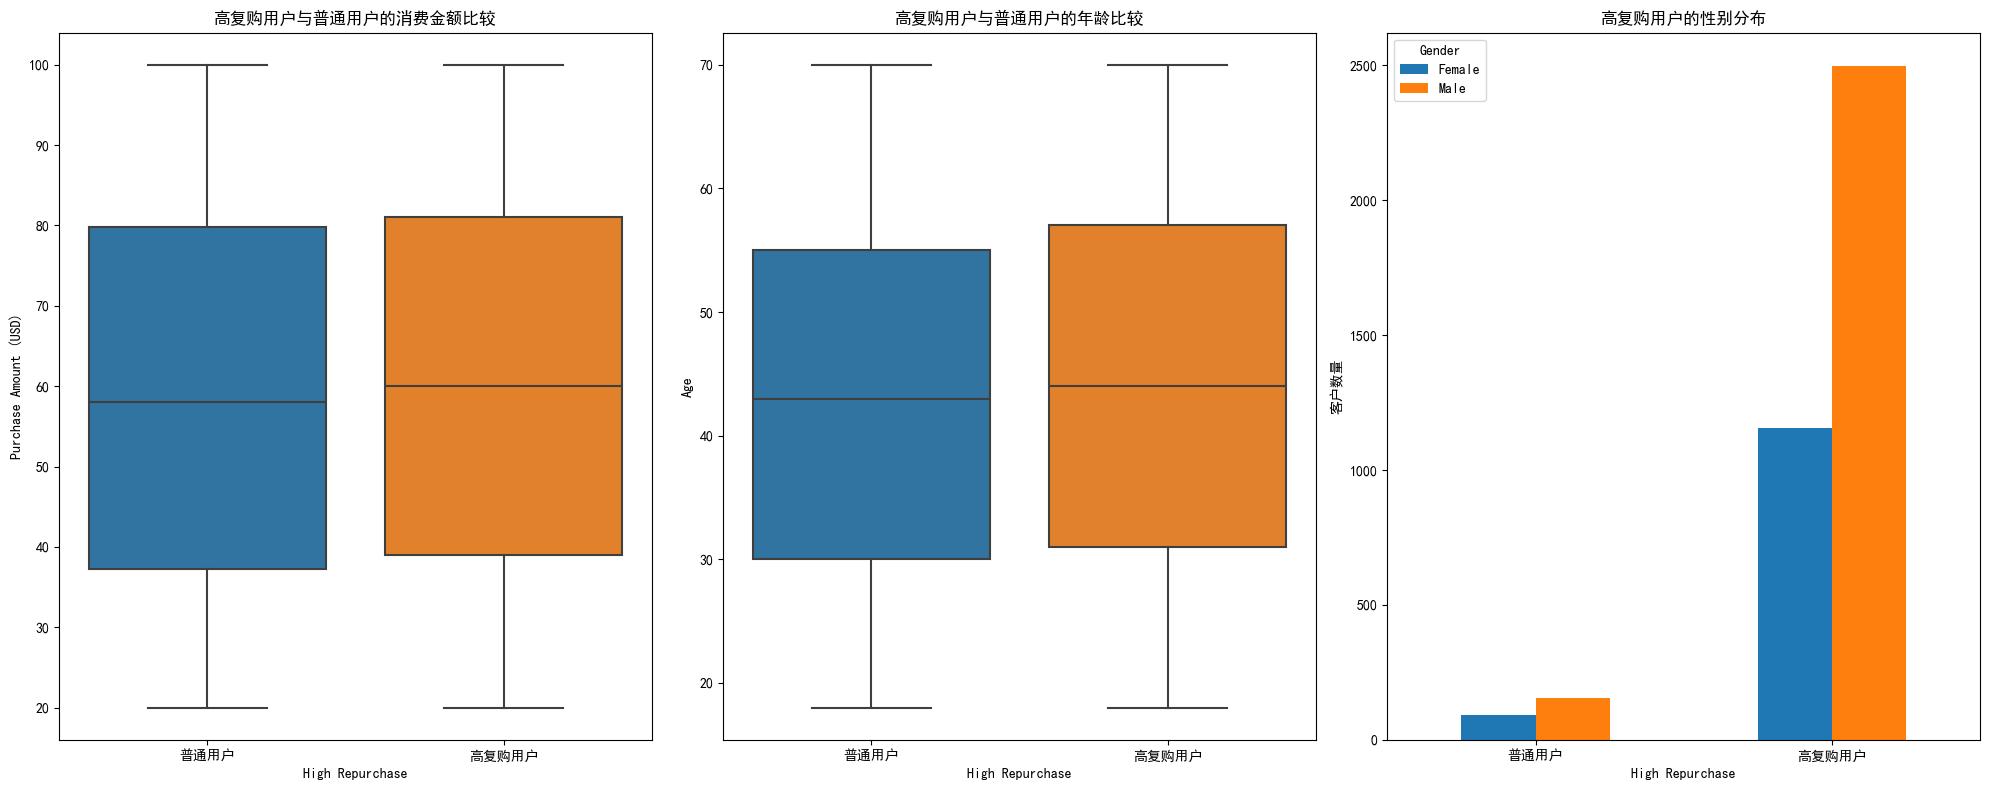

In [80]:

# 高复购用户画像特征可视化
plt.figure(figsize=(20, 8))

# 子图1: 高复购用户与普通用户的消费金额比较
plt.subplot(1, 3, 1)
sns.boxplot(x='High Repurchase', y='Purchase Amount (USD)', data=data)
plt.title('高复购用户与普通用户的消费金额比较')
plt.xticks([0, 1], ['普通用户', '高复购用户'])

# 子图2: 高复购用户与普通用户的年龄比较
plt.subplot(1, 3, 2)
sns.boxplot(x='High Repurchase', y='Age', data=data)
plt.title('高复购用户与普通用户的年龄比较')
plt.xticks([0, 1], ['普通用户', '高复购用户'])

# 子图3: 高复购用户的性别分布
plt.subplot(1, 3, 3)
gender_repurchase_plot = pd.crosstab(data['High Repurchase'], data['Gender'])
gender_repurchase_plot.plot(kind='bar', ax=plt.gca())
plt.title('高复购用户的性别分布')
plt.xticks([0, 1], ['普通用户', '高复购用户'], rotation=0)
plt.ylabel('客户数量')

plt.tight_layout()
plt.show()

In [81]:

# 高复购用户的行为特征
print("\n高复购用户的行为特征:")

# 支付方式偏好
payment_repurchase = pd.crosstab(data['High Repurchase'], data['Payment Method'], normalize='index') * 100
print("\n支付方式偏好(%):")
print(payment_repurchase.round(2))

# 订阅状态
subscription_repurchase = pd.crosstab(data['High Repurchase'], data['Subscription Status'], normalize='index') * 100
print("\n订阅状态(%):")
print(subscription_repurchase.round(2))

# 折扣使用情况
discount_repurchase = pd.crosstab(data['High Repurchase'], data['Discount Applied'], normalize='index') * 100
print("\n折扣使用情况(%):")
print(discount_repurchase.round(2))


高复购用户的行为特征:

支付方式偏好(%):
Payment Method   Bank Transfer   Cash  Credit Card  Debit Card  PayPal  Venmo
High Repurchase                                                              
False                    16.67  16.26        17.89       15.85   13.82  19.51
True                     16.17  16.64        17.84       16.26   16.53  16.56

订阅状态(%):
Subscription Status     No    Yes
High Repurchase                  
False                79.27  20.73
True                 72.58  27.42

折扣使用情况(%):
Discount Applied     No    Yes
High Repurchase               
False             57.72  42.28
True              56.95  43.05


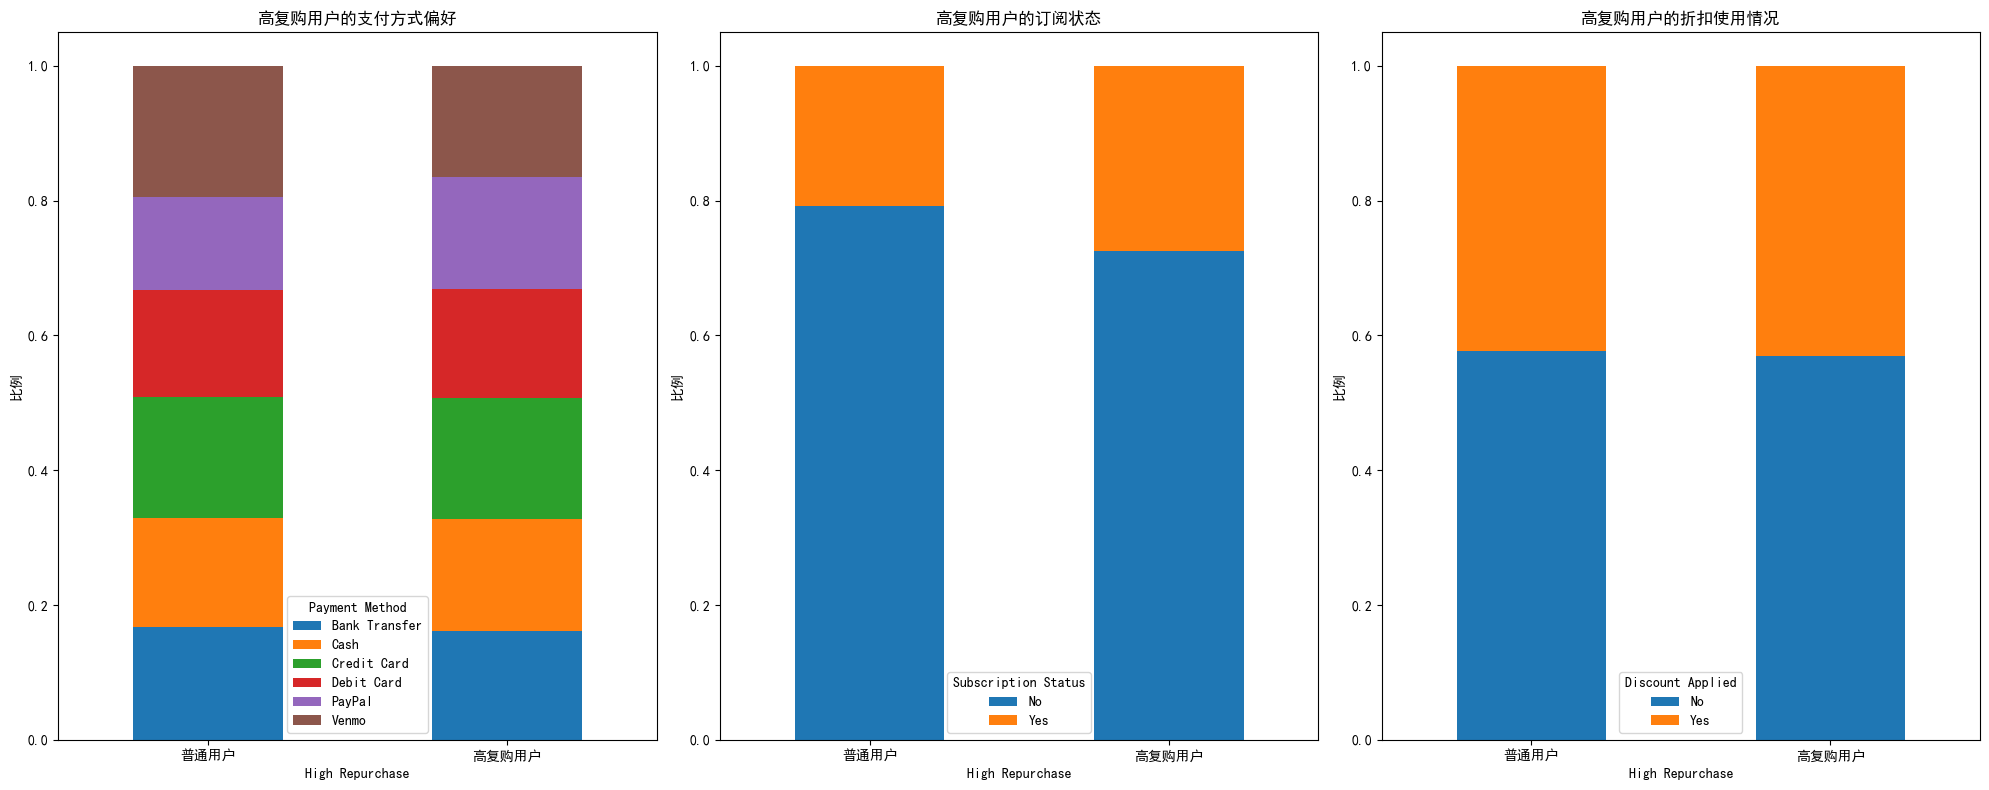

In [82]:

# 高复购用户特征可视化
plt.figure(figsize=(20, 8))

# 子图1: 高复购用户的支付方式偏好
plt.subplot(1, 3, 1)
payment_repurchase_plot = pd.crosstab(data['High Repurchase'], data['Payment Method'], normalize='index')
payment_repurchase_plot.plot(kind='bar', ax=plt.gca(), stacked=True)
plt.title('高复购用户的支付方式偏好')
plt.xticks([0, 1], ['普通用户', '高复购用户'], rotation=0)
plt.ylabel('比例')

# 子图2: 高复购用户的订阅状态
plt.subplot(1, 3, 2)
subscription_repurchase_plot = pd.crosstab(data['High Repurchase'], data['Subscription Status'], normalize='index')
subscription_repurchase_plot.plot(kind='bar', ax=plt.gca(), stacked=True)
plt.title('高复购用户的订阅状态')
plt.xticks([0, 1], ['普通用户', '高复购用户'], rotation=0)
plt.ylabel('比例')

# 子图3: 高复购用户的折扣使用情况
plt.subplot(1, 3, 3)
discount_repurchase_plot = pd.crosstab(data['High Repurchase'], data['Discount Applied'], normalize='index')
discount_repurchase_plot.plot(kind='bar', ax=plt.gca(), stacked=True)
plt.title('高复购用户的折扣使用情况')
plt.xticks([0, 1], ['普通用户', '高复购用户'], rotation=0)
plt.ylabel('比例')

plt.tight_layout()
plt.show()

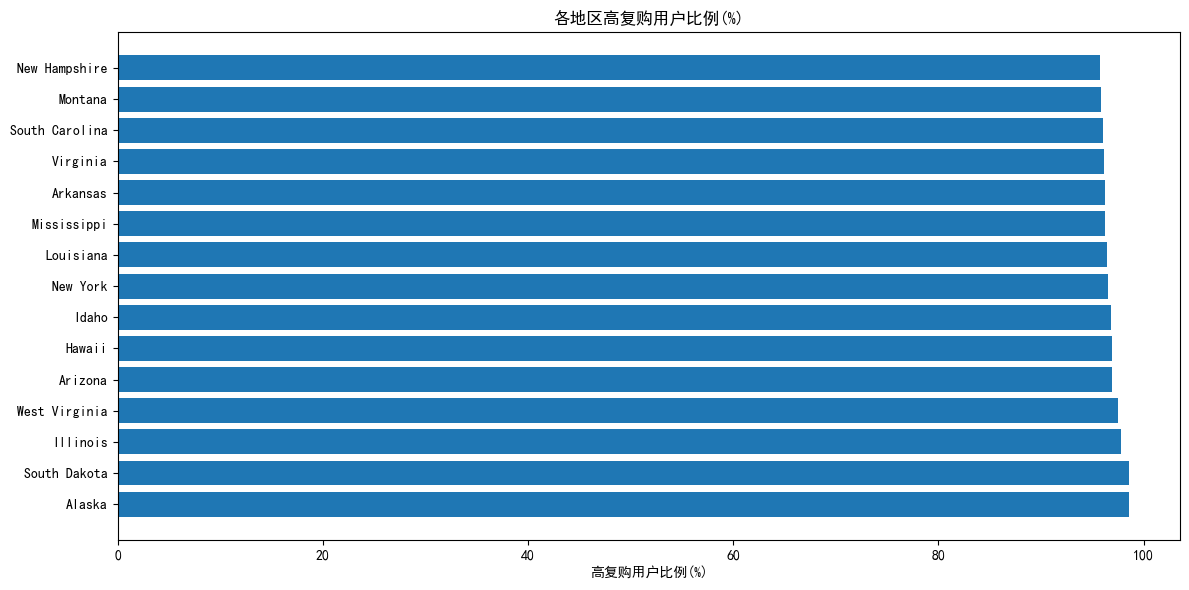

In [83]:

# 高复购用户的地理分布热力图
plt.figure(figsize=(12, 6))
location_repurchase_rate = data.groupby('Location')['High Repurchase'].mean().sort_values(ascending=False).head(15)
plt.barh(location_repurchase_rate.index, location_repurchase_rate.values * 100)
plt.title('各地区高复购用户比例(%)')
plt.xlabel('高复购用户比例(%)')
plt.tight_layout()
plt.show()

### 5.5.4 忠诚度评分模型

In [84]:

# 按照以下降序顺序赋予购买频率编码（7-1）：
# Bi-Weekly：一周两次
# Weekly：一周一次
# Fortnightly:两周一次
# Monthly： 一月一次
# Every 3 Months：三月一次
# Quarterly：一季一次
# Annually:一年一次

In [85]:

# 创建简单的忠诚度评分
# 基于历史购买次数、购买频率、消费金额、评分和订阅

# 标准化各项指标
from sklearn.preprocessing import MinMaxScaler

# 准备数据：历史购买次数、消费金额、评分
loyalty_data = data[['Previous Purchases', 'Purchase Amount (USD)', 'Review Rating']].copy()

# 购买频率编码
frequency_mapping = {'Bi-Weekly': 7, 'Weekly': 6, 'Fortnightly': 5, 'Monthly': 4, 'Every 3 Months': 3, 'Quarterly': 2, 'Annually': 1}
loyalty_data['Frequency Score'] = data['Frequency of Purchases'].map(frequency_mapping)

# 订阅状态编码
loyalty_data['Subscription Score'] = (data['Subscription Status'] == 'Yes').astype(int) * 2

# 标准化数据
scaler = MinMaxScaler()
loyalty_data_scaled = pd.DataFrame(
    scaler.fit_transform(loyalty_data),
    columns=loyalty_data.columns,
    index=loyalty_data.index
)

In [86]:

# 计算忠诚度评分 (加权平均)
weights = {
    'Previous Purchases': 0.3,     #历史购买次数
    'Purchase Amount (USD)': 0.2,  #消费金额和评分
    'Review Rating': 0.2,          #评分
    'Frequency Score': 0.2,        #购买频率
    'Subscription Score': 0.1      #订阅
}

data['Loyalty Score'] = (
    loyalty_data_scaled['Previous Purchases'] * weights['Previous Purchases'] +
    loyalty_data_scaled['Purchase Amount (USD)'] * weights['Purchase Amount (USD)'] +
    loyalty_data_scaled['Review Rating'] * weights['Review Rating'] +
    loyalty_data_scaled['Frequency Score'] * weights['Frequency Score'] +
    loyalty_data_scaled['Subscription Score'] * weights['Subscription Score']
) * 100
data['Loyalty Score']

0       44.342517
1       39.745578
2       58.186054
3       81.554422
4       37.217347
          ...    
3895    51.246259
3896    67.739796
3897    23.864966
3898    55.398299
3899    42.975170
Name: Loyalty Score, Length: 3900, dtype: float64

In [87]:

# 忠诚度分组
data['Loyalty Tier'] = pd.cut(data['Loyalty Score'], 
                             bins=[0, 30, 60, 80, 100],
                             labels=['青铜', '白银', '黄金', '铂金'])

# 忠诚度分组统计
loyalty_tier_counts = data['Loyalty Tier'].value_counts().sort_index()
loyalty_tier_percentage = (loyalty_tier_counts / len(data) * 100).round(2)

print("忠诚度分组统计:")
loyalty_summary = pd.DataFrame({
    '客户数量': loyalty_tier_counts,
    '占比(%)': loyalty_tier_percentage
})
print(loyalty_summary)

忠诚度分组统计:
              客户数量  占比(%)
Loyalty Tier             
青铜             473  12.13
白银            2641  67.72
黄金             739  18.95
铂金              47   1.21


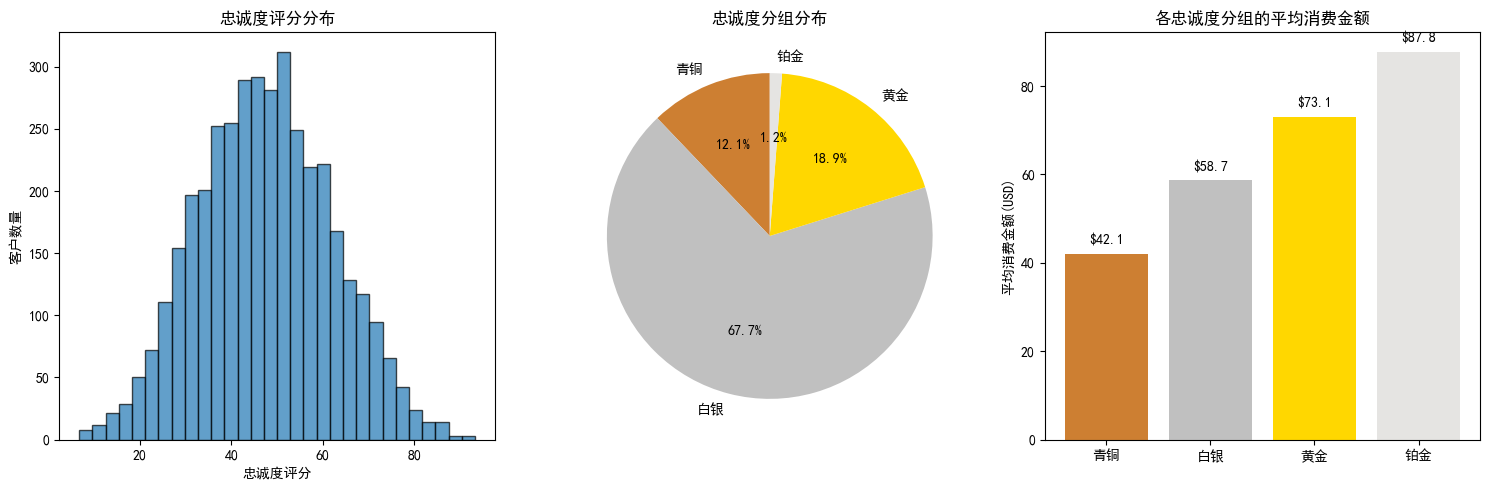

In [88]:

# 忠诚度评分可视化
plt.figure(figsize=(15, 5))

# 子图1: 忠诚度评分分布
plt.subplot(1, 3, 1)
plt.hist(data['Loyalty Score'], bins=30, edgecolor='black', alpha=0.7)
plt.title('忠诚度评分分布')
plt.xlabel('忠诚度评分')
plt.ylabel('客户数量')

# 子图2: 忠诚度分组分布
plt.subplot(1, 3, 2)
loyalty_colors = ['#CD7F32', '#C0C0C0', '#FFD700', '#E5E4E2']
plt.pie(loyalty_tier_counts.values, labels=loyalty_tier_counts.index, 
        autopct='%1.1f%%', startangle=90, colors=loyalty_colors)
plt.title('忠诚度分组分布')

# 子图3: 各忠诚度分组的平均消费金额
plt.subplot(1, 3, 3)
loyalty_purchase = data.groupby('Loyalty Tier')['Purchase Amount (USD)'].mean()
plt.bar(loyalty_purchase.index, loyalty_purchase.values, color=loyalty_colors)
plt.title('各忠诚度分组的平均消费金额')
plt.ylabel('平均消费金额(USD)')

# 在柱状图上添加数值标签
for i, v in enumerate(loyalty_purchase.values):
    plt.text(i, v + 2, f'${v:.1f}', ha='center')

plt.tight_layout()
plt.show()

### 综合分析与建议

In [90]:

print("复购与忠诚度综合分析")
print("=" * 150)

# 1. 主要发现 - 复购情况
repurchase_percentage = (data['Previous Purchases'] >= 1).sum() / len(data) * 100
print(f"1. 复购客户占比: {repurchase_percentage:.2f}%")
print(f"2. 高复购客户(≥{high_repurchase_threshold}次)占比: {high_repurchase_percentage:.2f}%")

# 2. 主要发现 - 高复购用户特征
high_repurchase_avg_age = data[data['High Repurchase']]['Age'].mean()
high_repurchase_avg_spending = data[data['High Repurchase']]['Purchase Amount (USD)'].mean()
print(f"3. 高复购用户平均年龄: {high_repurchase_avg_age:.1f}岁")
print(f"4. 高复购用户平均消费金额: ${high_repurchase_avg_spending:.2f}")

# 3. 主要发现 - 忠诚度
top_loyalty_tier = loyalty_tier_counts.idxmax()
top_loyalty_percentage = loyalty_tier_percentage[top_loyalty_tier]
print(f"5. 最高忠诚度分组: {top_loyalty_tier}, 占比{top_loyalty_percentage}%")

# 提出客户忠诚度提升建议
print("\n客户忠诚度提升建议:")
print("1. 高价值客户识别与维护:")
print("   - 建立客户分层体系，识别高复购和高忠诚度客户")
print("   - 为铂金和黄金级别客户提供专属服务和优惠")
print("   - 定期分析高价值客户流失风险，提前干预")

print("\n2. 复购促进策略:")
print("   - 为新客户设计首单优惠+复购激励组合策略")
print("   - 建立智能推荐系统，基于购买历史推荐相关产品")
print("   - 设置购买里程碑奖励，鼓励客户提升购买频次")

print("\n3. 个性化互动:")
print("   - 基于购买频率和偏好，设计个性化营销信息")
print("   - 为不同忠诚度层级客户提供差异化服务体验")
print("   - 建立客户生日、纪念日等特殊时点的关怀计划")

print("\n4. 订阅服务优化:")
print("   - 分析高复购客户的订阅偏好，优化订阅服务内容")
print("   - 设计订阅服务阶梯优惠，鼓励长期订阅")
print("   - 提供灵活的订阅调整和暂停功能，降低取消率")

print("\n5. 数据驱动决策:")
print("   - 定期监控复购率和忠诚度指标变化趋势")
print("   - 建立客户生命周期价值(LTV)预测模型")
print("   - 开展A/B测试，优化忠诚度计划设计")

# 关键指标监控建议
print("\n关键监控指标:")
print(f"   - 整体复购率目标: >{high_repurchase_percentage * 1.1:.1f}% (+10%)")
print(f"   - 高复购客户占比目标: >{high_repurchase_percentage * 1.15:.1f}% (+15%)")
print(f"   - 铂金忠诚度客户占比目标: >{loyalty_tier_percentage['铂金'] * 1.2:.1f}% (+20%)")
print(f"   - 高复购客户平均消费金额目标: ${high_repurchase_avg_spending * 1.05:.2f} (+5%)")

复购与忠诚度综合分析
1. 复购客户占比: 100.00%
2. 高复购客户(≥4次)占比: 93.69%
3. 高复购用户平均年龄: 44.1岁
4. 高复购用户平均消费金额: $59.81
5. 最高忠诚度分组: 白银, 占比67.72%

客户忠诚度提升建议:
1. 高价值客户识别与维护:
   - 建立客户分层体系，识别高复购和高忠诚度客户
   - 为铂金和黄金级别客户提供专属服务和优惠
   - 定期分析高价值客户流失风险，提前干预

2. 复购促进策略:
   - 为新客户设计首单优惠+复购激励组合策略
   - 建立智能推荐系统，基于购买历史推荐相关产品
   - 设置购买里程碑奖励，鼓励客户提升购买频次

3. 个性化互动:
   - 基于购买频率和偏好，设计个性化营销信息
   - 为不同忠诚度层级客户提供差异化服务体验
   - 建立客户生日、纪念日等特殊时点的关怀计划

4. 订阅服务优化:
   - 分析高复购客户的订阅偏好，优化订阅服务内容
   - 设计订阅服务阶梯优惠，鼓励长期订阅
   - 提供灵活的订阅调整和暂停功能，降低取消率

5. 数据驱动决策:
   - 定期监控复购率和忠诚度指标变化趋势
   - 建立客户生命周期价值(LTV)预测模型
   - 开展A/B测试，优化忠诚度计划设计

关键监控指标:
   - 整体复购率目标: >103.1% (+10%)
   - 高复购客户占比目标: >107.7% (+15%)
   - 铂金忠诚度客户占比目标: >1.5% (+20%)
   - 高复购客户平均消费金额目标: $62.80 (+5%)


## 用户反馈分析

### 5.6.1 评分情况

In [92]:

# 计算各品类的平均评分
category_rating = data.groupby('Category')['Review Rating'].agg(['mean', 'count']).round(2)
category_rating.columns = ['平均评分', '订单数量']
category_rating = category_rating.sort_values('平均评分', ascending=False)

print("\n各品类的平均评分:")
print(category_rating)

# 计算各商品的平均评分 (至少有10个评价的商品)
item_rating = data.groupby('Item Purchased')['Review Rating'].agg(['mean', 'count']).round(2)
item_rating.columns = ['平均评分', '评价数量']
item_rating = item_rating[item_rating['评价数量'] >= 10].sort_values('平均评分', ascending=False)

print("\n各商品的平均评分 (至少10个评价):")
print(item_rating.head(10))


各品类的平均评分:
             平均评分  订单数量
Category               
Footwear     3.79   599
Accessories  3.77  1240
Outerwear    3.75   324
Clothing     3.72  1737

各商品的平均评分 (至少10个评价):
                平均评分  评价数量
Item Purchased            
Gloves          3.86   140
Sandals         3.84   160
Boots           3.81   144
Hat             3.81   154
T-shirt         3.78   147
Skirt           3.78   158
Handbag         3.78   153
Sweater         3.77   164
Belt            3.76   161
Sneakers        3.76   145


In [93]:

# 创建评分分组
data['Rating Group'] = pd.cut(data['Review Rating'], 
                             bins=[0, 2.5, 3.5, 4.5, 5.1],
                             labels=['差评(≤2.5)', '中评(2.6-3.5)', '好评(3.6-4.5)', '极好评(4.6-5.0)'])

# 评分分组统计
rating_group_counts = data['Rating Group'].value_counts().sort_index()
rating_group_percentage = (rating_group_counts / len(data) * 100).round(2)

print("\n评分分组统计:")
rating_summary = pd.DataFrame({
    '订单数量': rating_group_counts,
    '占比(%)': rating_group_percentage
})
print(rating_summary)


评分分组统计:
              订单数量  占比(%)
Rating Group             
差评(≤2.5)        66   1.69
中评(2.6-3.5)   1580  40.51
好评(3.6-4.5)   1554  39.85
极好评(4.6-5.0)   700  17.95


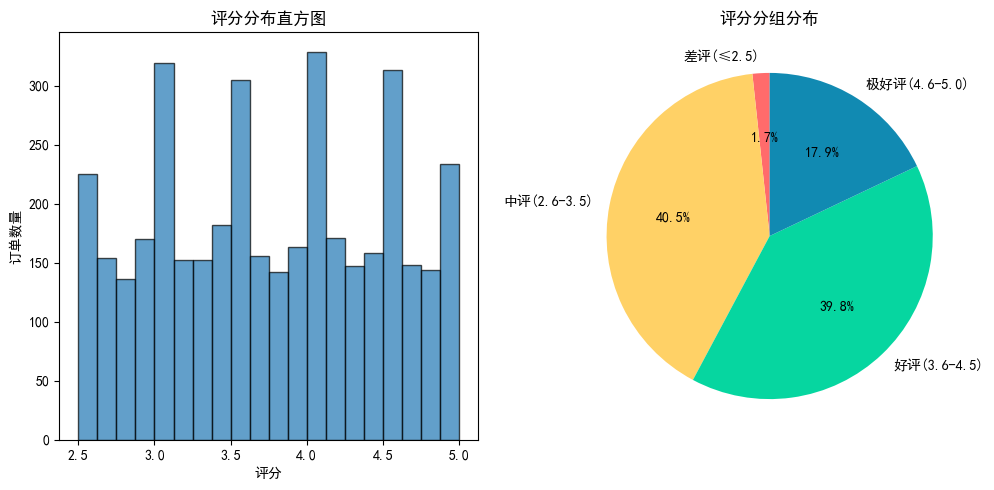

In [94]:

# 评分分布可视化
plt.figure(figsize=(15, 5))

# 子图1: 评分分布直方图
plt.subplot(1, 3, 1)
plt.hist(data['Review Rating'], bins=20, edgecolor='black', alpha=0.7)
plt.title('评分分布直方图')
plt.xlabel('评分')
plt.ylabel('订单数量')

# 子图2: 评分分组饼图
plt.subplot(1, 3, 2)
rating_colors = ['#FF6B6B', '#FFD166', '#06D6A0', '#118AB2']
plt.pie(rating_group_counts.values, labels=rating_group_counts.index, 
        autopct='%1.1f%%', startangle=90, colors=rating_colors)
plt.title('评分分组分布')

plt.tight_layout()
plt.show()

### 5.6.2 高评分与低评分订单的商品/品类特征

In [95]:

# 定义高评分和低评分
high_rating_threshold = 4.0
low_rating_threshold = 3.0

data['High Rating'] = data['Review Rating'] >= high_rating_threshold
data['Low Rating'] = data['Review Rating'] <= low_rating_threshold

high_rating_count = data['High Rating'].sum()
low_rating_count = data['Low Rating'].sum()

print(f"高评分(≥{high_rating_threshold})订单数量: {high_rating_count} ({(high_rating_count/len(data)*100):.2f}%)")
print(f"低评分(≤{low_rating_threshold})订单数量: {low_rating_count} ({(low_rating_count/len(data)*100):.2f}%)")

高评分(≥4.0)订单数量: 1644 (42.15%)
低评分(≤3.0)订单数量: 847 (21.72%)


In [96]:

# 高评分与低评分订单的品类分布
print("\n高评分与低评分订单的品类分布:")

# 高评分订单的品类分布
high_rating_category = data[data['High Rating']]['Category'].value_counts()
high_rating_category_percentage = (high_rating_category / high_rating_count * 100).round(2)

print("\n高评分订单的品类分布:")
high_rating_category_summary = pd.DataFrame({
    '订单数量': high_rating_category,
    '占比(%)': high_rating_category_percentage
})
print(high_rating_category_summary)

# 低评分订单的品类分布
low_rating_category = data[data['Low Rating']]['Category'].value_counts()
low_rating_category_percentage = (low_rating_category / low_rating_count * 100).round(2)

print("\n低评分订单的品类分布:")
low_rating_category_summary = pd.DataFrame({
    '订单数量': low_rating_category,
    '占比(%)': low_rating_category_percentage
})
print(low_rating_category_summary)


高评分与低评分订单的品类分布:

高评分订单的品类分布:
             订单数量  占比(%)
Category                
Clothing      698  42.46
Accessories   535  32.54
Footwear      270  16.42
Outerwear     141   8.58

低评分订单的品类分布:
             订单数量  占比(%)
Category                
Clothing      400  47.23
Accessories   255  30.11
Footwear      123  14.52
Outerwear      69   8.15


In [97]:

# 高评分与低评分订单的商品分布 (前10商品)
print("\n高评分与低评分订单的商品分布 (前10商品):")

# 高评分订单的商品分布
high_rating_item = data[data['High Rating']]['Item Purchased'].value_counts().head(10)
print("\n高评分订单的前10商品:")
print(high_rating_item)

# 低评分订单的商品分布
low_rating_item = data[data['Low Rating']]['Item Purchased'].value_counts().head(10)
print("\n低评分订单的前10商品:")
print(low_rating_item)


高评分与低评分订单的商品分布 (前10商品):

高评分订单的前10商品:
Item Purchased
Sandals    80
Jewelry    74
Jacket     73
Hat        71
Sweater    70
Belt       70
Boots      69
Blouse     68
Coat       68
Skirt      68
Name: count, dtype: int64

低评分订单的前10商品:
Item Purchased
Shirt         51
Blouse        42
Shorts        40
Pants         39
Sweater       39
Coat          37
Jewelry       37
Sunglasses    36
Scarf         36
Hoodie        36
Name: count, dtype: int64


In [98]:

# 高评分与低评分订单的颜色偏好
print("\n高评分与低评分订单的颜色偏好:")

# 高评分订单的颜色分布
high_rating_color = data[data['High Rating']]['Color'].value_counts().head(10)
print("\n高评分订单的前10颜色:")
print(high_rating_color)

# 低评分订单的颜色分布
low_rating_color = data[data['Low Rating']]['Color'].value_counts().head(10)
print("\n低评分订单的前10颜色:")
print(low_rating_color)


高评分与低评分订单的颜色偏好:

高评分订单的前10颜色:
Color
Gray        84
Yellow      84
Black       82
Orange      74
Olive       74
Magenta     74
Charcoal    73
Silver      73
Maroon      73
Teal        70
Name: count, dtype: int64

低评分订单的前10颜色:
Color
Cyan      49
Peach     41
Olive     41
Beige     39
Red       38
Blue      37
Teal      36
Gray      36
Silver    35
Green     35
Name: count, dtype: int64


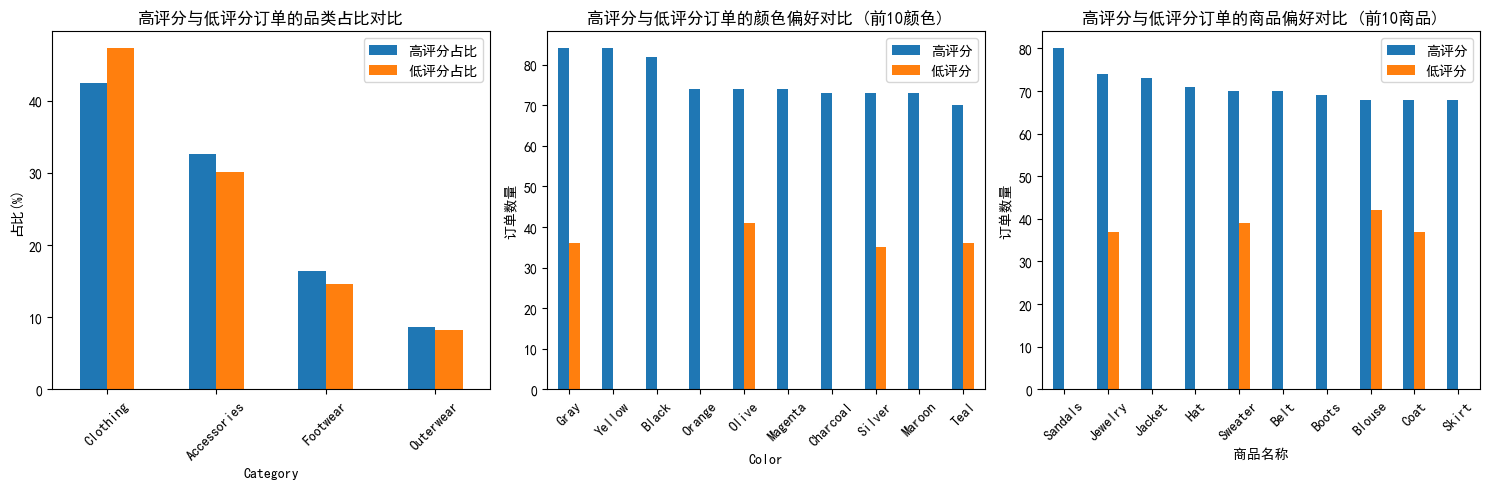

In [99]:

# 高评分与低评分订单的品类分布可视化
plt.figure(figsize=(15, 5))

# 子图1: 高评分与低评分订单的品类占比对比
category_rating_comparison = pd.DataFrame({
    '高评分占比': high_rating_category_percentage,
    '低评分占比': low_rating_category_percentage.reindex(high_rating_category_percentage.index, fill_value=0)
})
category_rating_comparison.plot(kind='bar', ax=plt.subplot(1, 3, 1))
plt.title('高评分与低评分订单的品类占比对比')
plt.ylabel('占比(%)')
plt.xticks(rotation=45)

# 子图2: 高评分与低评分订单的颜色偏好对比 (前10颜色)
top_colors = high_rating_color.head(10).index # 获取高评分订单的前10颜色作为基准
color_rating_comparison = pd.DataFrame({
    '高评分': high_rating_color.reindex(top_colors, fill_value=0),
    '低评分': low_rating_color.reindex(top_colors, fill_value=0)
})
color_rating_comparison.plot(kind='bar', ax=plt.subplot(1, 3, 2))
plt.title('高评分与低评分订单的颜色偏好对比 (前10颜色)')
plt.ylabel('订单数量')
plt.xticks(rotation=45)

# 子图3: 高评分与低评分订单的商品偏好对比 (前10商品)
top_items = high_rating_item.head(10).index # 获取高评分订单的前10商品作为基准

# 创建对比DataFrame
item_rating_comparison = pd.DataFrame({
    '高评分': high_rating_item.reindex(top_items, fill_value=0),
    '低评分': low_rating_item.reindex(top_items, fill_value=0)
})
item_rating_comparison.plot(kind='bar', ax=plt.subplot(1, 3, 3))
plt.title('高评分与低评分订单的商品偏好对比 (前10商品)')
plt.ylabel('订单数量')
plt.xlabel('商品名称')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 5.6.3 评分与购买金额，折扣使用等的关系

In [100]:

# 评分与购买金额的关系
print("评分与购买金额的关系:")
rating_amount_corr = data['Review Rating'].corr(data['Purchase Amount (USD)'])
print(f"评分与购买金额的相关系数: {rating_amount_corr:.3f}")

# 按评分分组分析购买金额
rating_amount = data.groupby('Rating Group')['Purchase Amount (USD)'].agg(['mean', 'median', 'std', 'count']).round(2)
rating_amount.columns = ['平均金额', '中位数', '标准差', '订单数量']
print("各评分分组的购买金额分析:")
print(rating_amount)

# 评分与折扣使用的关系
print("\n评分与折扣使用的关系:")
rating_discount = pd.crosstab(data['Rating Group'], data['Discount Applied'], normalize='index') * 100
print("各评分分组的折扣使用率(%):")
print(rating_discount.round(2))

评分与购买金额的关系:
评分与购买金额的相关系数: 0.031
各评分分组的购买金额分析:
               平均金额   中位数    标准差  订单数量
Rating Group                          
差评(≤2.5)      62.29  65.5  22.29    66
中评(2.6-3.5)   59.10  58.0  23.27  1580
好评(3.6-4.5)   59.78  60.0  23.88  1554
极好评(4.6-5.0)  61.00  63.0  24.27   700

评分与折扣使用的关系:
各评分分组的折扣使用率(%):
Discount Applied     No    Yes
Rating Group                  
差评(≤2.5)          53.03  46.97
中评(2.6-3.5)       56.58  43.42
好评(3.6-4.5)       57.08  42.92
极好评(4.6-5.0)      58.14  41.86


In [101]:

# 评分与订阅状态的关系
print("评分与订阅状态的关系:")
rating_subscription = pd.crosstab(data['Rating Group'], data['Subscription Status'], normalize='index') * 100
print("各评分分组的订阅率(%):")
print(rating_subscription.round(2))

# 评分与配送方式的关系
print("\n评分与配送方式的关系:")
rating_shipping = pd.crosstab(data['Rating Group'], data['Shipping Type'], normalize='index') * 100
print("各评分分组的配送方式分布(%):")
print(rating_shipping.round(2))


评分与订阅状态的关系:
各评分分组的订阅率(%):
Subscription Status     No    Yes
Rating Group                     
差评(≤2.5)             71.21  28.79
中评(2.6-3.5)          72.66  27.34
好评(3.6-4.5)          73.55  26.45
极好评(4.6-5.0)         72.71  27.29

评分与配送方式的关系:
各评分分组的配送方式分布(%):
Shipping Type  2-Day Shipping  Express  Free Shipping  Next Day Air  Standard  \
Rating Group                                                                    
差评(≤2.5)                12.12    13.64          19.70         27.27     12.12   
中评(2.6-3.5)             15.95    15.32          18.35         17.34     15.32   
好评(3.6-4.5)             16.54    17.70          16.22         15.64     17.82   
极好评(4.6-5.0)            15.71    17.14          17.14         16.14     18.14   

Shipping Type  Store Pickup  
Rating Group                 
差评(≤2.5)              15.15  
中评(2.6-3.5)           17.72  
好评(3.6-4.5)           16.09  
极好评(4.6-5.0)          15.71  


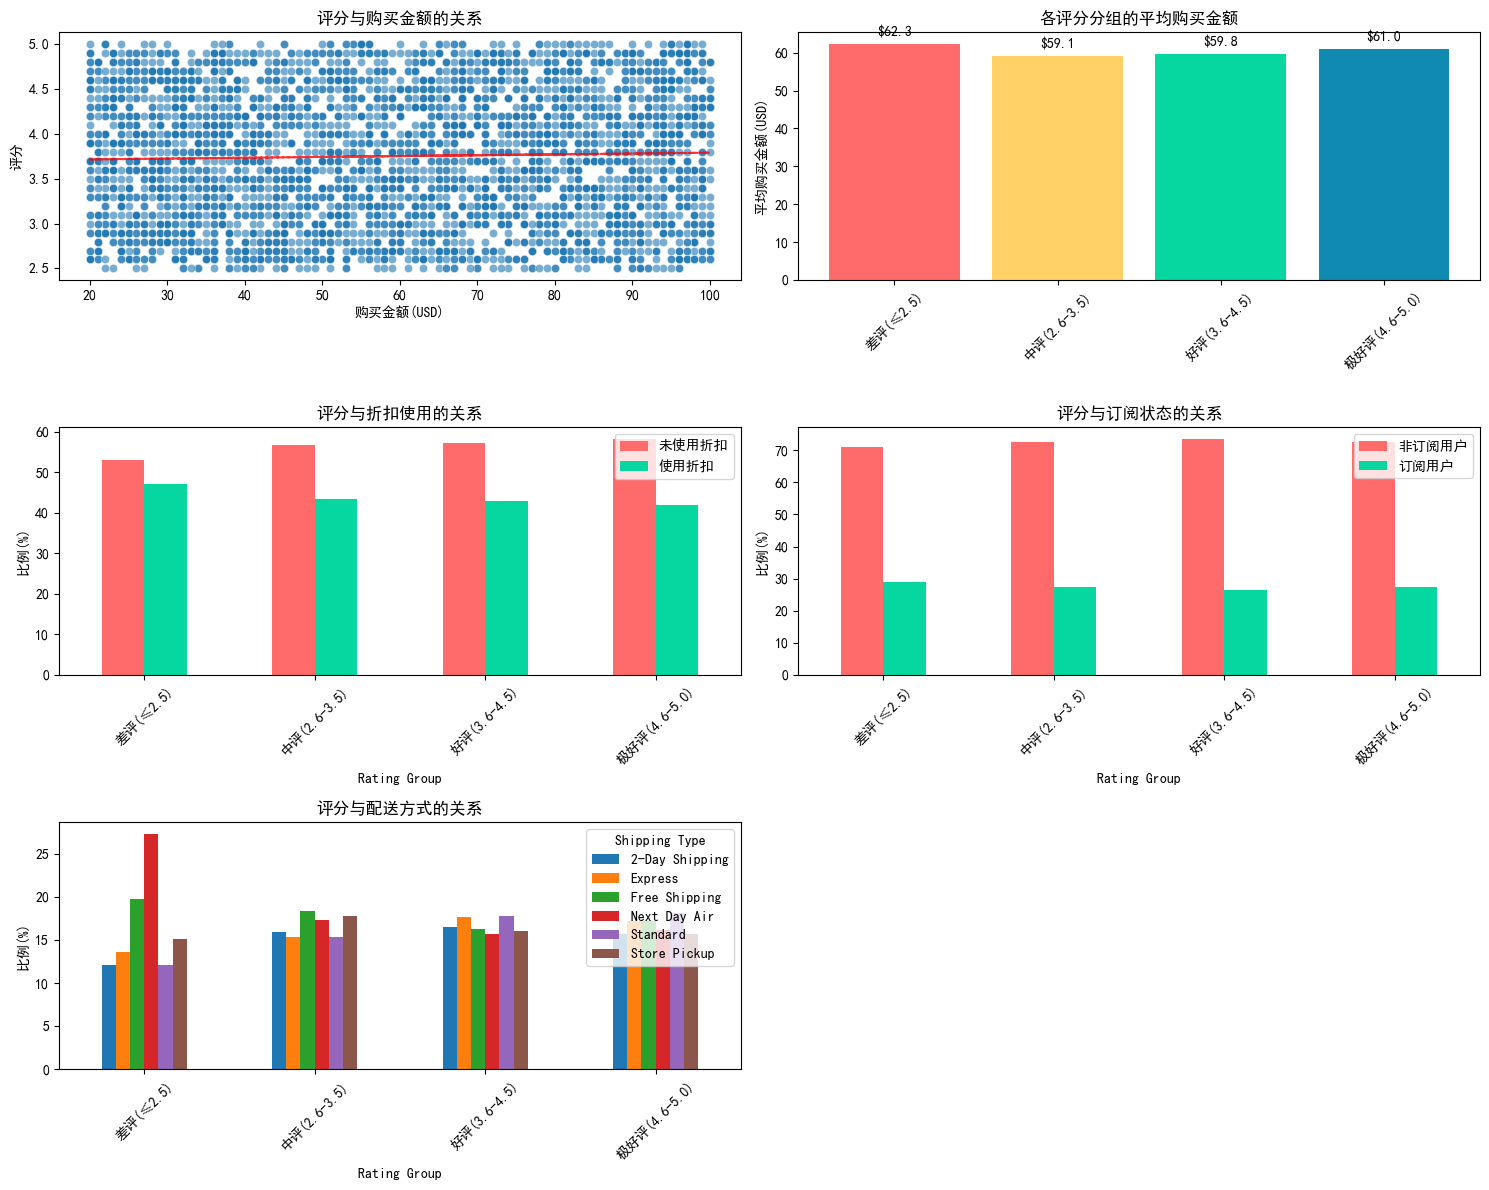

In [102]:

# 评分与其他因素的关系可视化
plt.figure(figsize=(15, 12))

# 子图1: 评分与购买金额的关系
plt.subplot(3, 2, 1)
sns.scatterplot(x='Purchase Amount (USD)', y='Review Rating', data=data, alpha=0.6)
plt.title('评分与购买金额的关系')
plt.xlabel('购买金额(USD)')
plt.ylabel('评分')
# 添加趋势线
z = np.polyfit(data['Purchase Amount (USD)'], data['Review Rating'], 1)
p = np.poly1d(z)
plt.plot(data['Purchase Amount (USD)'], p(data['Purchase Amount (USD)']), "r--", alpha=0.8)

# 子图2: 各评分分组的平均购买金额
plt.subplot(3, 2, 2)
plt.bar(rating_amount.index, rating_amount['平均金额'], color=rating_colors)
plt.title('各评分分组的平均购买金额')
plt.ylabel('平均购买金额(USD)')
plt.xticks(rotation=45)

# 在柱状图上添加数值标签
for i, v in enumerate(rating_amount['平均金额']):
    plt.text(i, v + 2, f'${v:.1f}', ha='center')

# 子图3: 评分与折扣使用的关系
plt.subplot(3, 2, 3)
rating_discount.plot(kind='bar', ax=plt.gca(), color=['#FF6B6B', '#06D6A0'])
plt.title('评分与折扣使用的关系')
plt.ylabel('比例(%)')
plt.xticks(rotation=45)
plt.legend(['未使用折扣', '使用折扣'])

# 子图4: 评分与订阅状态的关系
plt.subplot(3, 2, 4)
rating_subscription.plot(kind='bar', ax=plt.gca(), color=['#FF6B6B', '#06D6A0'])
plt.title('评分与订阅状态的关系')
plt.ylabel('比例(%)')
plt.xticks(rotation=45)
plt.legend(['非订阅用户', '订阅用户'])

# 子图5: 评分与配送方式的关系
plt.subplot(3, 2, 5)
rating_shipping.plot(kind='bar', ax=plt.gca())
plt.title('评分与配送方式的关系')
plt.ylabel('比例(%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 5.6.4 逻辑回归分析-预测高评分的因素

In [103]:

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print("高评分影响因素的逻辑回归分析:")
# 准备数据
data_analysis = data.copy()

# 编码所有分类变量
le = LabelEncoder()
categorical_cols = ['Category', 'Shipping Type', 'Payment Method', 'Frequency of Purchases']

# for col in categorical_cols:
#    df_analysis[col] = le.fit_transform(df_analysis[col])
# 报错：ValueError: could not convert string to float: 'Yes'
# 检查并编码所有可能包含字符串值的列
for col in data_analysis.columns:
    if data_analysis[col].dtype == 'object':  # 如果是对象类型（可能包含字符串）
        try:
            # 尝试转换为数值类型
            data_analysis[col] = pd.to_numeric(data_analysis[col])
        except ValueError:
            # 如果转换失败，使用标签编码
            data_analysis[col] = le.fit_transform(data_analysis[col].astype(str))

# 创建目标变量：是否为高评分
data_analysis['High_Rating'] = (data_analysis['Review Rating'] >= high_rating_threshold).astype(int)

# 选择特征
features = ['Purchase Amount (USD)', 'Age', 'Previous Purchases', 'Category', 
            'Shipping Type', 'Payment Method', 'Frequency of Purchases',
            'Discount Applied', 'Promo Code Used', 'Subscription Status']
X = data_analysis[features]
y = data_analysis['High_Rating']

# 拆分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练模型
model = LogisticRegression(max_iter=1000)  # 增加最大迭代次数以确保收敛
# 旧：model = LogisticRegression() 
model.fit(X_train, y_train)

# 输出特征重要性
feature_importance = pd.DataFrame({
    '特征': features,
    '系数': model.coef_[0]
}).sort_values('系数', ascending=False)

print("影响高评分的因素（系数越大，影响越正向）:")
print(feature_importance)

# 模型评估
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"\n模型准确率: 训练集={train_score:.3f}, 测试集={test_score:.3f}")

高评分影响因素的逻辑回归分析:
影响高评分的因素（系数越大，影响越正向）:
                       特征        系数
7        Discount Applied  0.013856
8         Promo Code Used  0.013856
3                Category  0.013048
2      Previous Purchases  0.003203
0   Purchase Amount (USD)  0.002812
6  Frequency of Purchases -0.003264
1                     Age -0.003622
4           Shipping Type -0.003949
5          Payment Method -0.027182
9     Subscription Status -0.070549

模型准确率: 训练集=0.580, 测试集=0.568


### 综合分析与建议

In [104]:

print("用户反馈综合分析")
print("=" * 150)

# 1. 主要发现 - 评分分布
avg_rating = data['Review Rating'].mean()
median_rating = data['Review Rating'].median()
print(f"1. 平均评分: {avg_rating:.2f}, 中位数评分: {median_rating:.2f}")
print(f"2. 高评分(≥{high_rating_threshold})订单占比: {(high_rating_count/len(data)*100):.2f}%")
print(f"3. 低评分(≤{low_rating_threshold})订单占比: {(low_rating_count/len(data)*100):.2f}%")

# 2. 主要发现 - 品类与评分
highest_rated_category = category_rating['平均评分'].idxmax()
highest_rating = category_rating['平均评分'].max()
lowest_rated_category = category_rating['平均评分'].idxmin()
lowest_rating = category_rating['平均评分'].min()
print(f"4. 评分最高的品类: {highest_rated_category}, 平均评分: {highest_rating}")
print(f"5. 评分最低的品类: {lowest_rated_category}, 平均评分: {lowest_rating}")

# 3. 主要发现 - 评分与其他因素的关系
print(f"6. 评分与购买金额的相关系数: {rating_amount_corr:.3f}")
print(f"7. 高评分订单平均金额: ${rating_amount.loc['极好评(4.6-5.0)', '平均金额']:.2f}")
print(f"8. 低评分订单平均金额: ${rating_amount.loc['差评(≤2.5)', '平均金额']:.2f}")

# 提出改进建议
print("\n改进建议:")
print("1. 产品与服务质量提升:")
print(f"   - 重点关注{lowest_rated_category}品类的质量改进")
print("   - 分析低评分订单的共同特征，识别系统性问题")
print("   - 建立产品质量监控机制，预防质量问题")

print("\n2. 客户体验优化:")
print("   - 优化高价值客户的购物体验，提高评分")
print("   - 改进配送服务，减少因配送问题导致的低评分")
print("   - 提供更灵活的退换货政策，增强客户信任")

print("\n3. 反馈机制完善:")
print("   - 建立主动的客户反馈收集机制")
print("   - 对低评分订单进行回访，了解具体问题")
print("   - 定期分析评分趋势，及时发现潜在问题")

print("\n4. 促销策略调整:")
print("   - 分析折扣和促销码对评分的影响，优化促销策略")
print("   - 避免过度促销导致的客户期望值管理问题")
print("   - 为高价值客户提供专属优惠，提高满意度")

print("\n5. 数据驱动决策:")
print("   - 建立评分预警系统，及时发现异常低评分")
print("   - 定期进行客户满意度调研，补充评分数据")
print("   - 将评分指标纳入绩效考核体系，提升服务质量")

# 关键指标监控建议
print("\n关键监控指标:")
print(f"   - 整体平均评分目标: >{avg_rating * 1.05:.2f} (+5%)")
print(f"   - 高评分订单占比目标: >{(high_rating_count/len(data)*100)*1.1:.1f}% (+10%)")
print(f"   - 低评分订单占比目标: <{(low_rating_count/len(data)*100)*0.8:.1f}% (-20%)")
print(f"   - {lowest_rated_category}品类评分目标: >{lowest_rating * 1.15:.2f} (+15%)")

用户反馈综合分析
1. 平均评分: 3.75, 中位数评分: 3.70
2. 高评分(≥4.0)订单占比: 42.15%
3. 低评分(≤3.0)订单占比: 21.72%
4. 评分最高的品类: Footwear, 平均评分: 3.79
5. 评分最低的品类: Clothing, 平均评分: 3.72
6. 评分与购买金额的相关系数: 0.031
7. 高评分订单平均金额: $61.00
8. 低评分订单平均金额: $62.29

改进建议:
1. 产品与服务质量提升:
   - 重点关注Clothing品类的质量改进
   - 分析低评分订单的共同特征，识别系统性问题
   - 建立产品质量监控机制，预防质量问题

2. 客户体验优化:
   - 优化高价值客户的购物体验，提高评分
   - 改进配送服务，减少因配送问题导致的低评分
   - 提供更灵活的退换货政策，增强客户信任

3. 反馈机制完善:
   - 建立主动的客户反馈收集机制
   - 对低评分订单进行回访，了解具体问题
   - 定期分析评分趋势，及时发现潜在问题

4. 促销策略调整:
   - 分析折扣和促销码对评分的影响，优化促销策略
   - 避免过度促销导致的客户期望值管理问题
   - 为高价值客户提供专属优惠，提高满意度

5. 数据驱动决策:
   - 建立评分预警系统，及时发现异常低评分
   - 定期进行客户满意度调研，补充评分数据
   - 将评分指标纳入绩效考核体系，提升服务质量

关键监控指标:
   - 整体平均评分目标: >3.94 (+5%)
   - 高评分订单占比目标: >46.4% (+10%)
   - 低评分订单占比目标: <17.4% (-20%)
   - Clothing品类评分目标: >4.28 (+15%)


# 六. 结论与建议：

一、营销策略建议

客户分层与精准营销
铂金客户计划：为忠诚度评分前10%的客户提供专属服务、提前访问新品和独家活动
复购激励计划：设置购买里程碑奖励（如第5次购买享8折，第10次购买享7折）

针对高复购用户（如26-35岁群体）设计忠诚度计划，如积分兑换、生日特权等，进一步提升用户粘性。

沉睡客户唤醒：针对90天内未购买的客户推送个性化优惠券和产品推荐

个性化推荐与交叉销售
基于购买历史的推荐：为高复购客户推荐互补品类产品（如购买上衣推荐下装）
女性用户虽数量少但消费力强，可加强女性导向的商品推荐与个性化营销。

季节性营销：根据季节变化推送相应产品（冬季推外套，夏季推T恤）

颜色偏好营销：向偏好黑色和蓝色的客户优先推送这些颜色的新品

促销策略优化
折扣使用并未带来金额提升，反而可能吸引价格敏感用户。建议设计“满减”或“赠品”类促销，避免单纯降价对品牌价值的影响。
36-55岁用户虽占比高，但消费金额未见突出，建议推出组合优惠或会员专享活动提升其客单价。

智能折扣策略：基于客户价值和购买历史提供个性化折扣力度

捆绑销售：将高评分产品与低销量产品捆绑销售，提升整体销售额

订阅优惠：为订阅用户提供专属折扣和提前抢购特权，提高订阅率

二、库存与采购建议

品类优化策略
加大优势品类：增加Clothing品类库存深度，特别是畅销款式和颜色
提升高价值品类：扩大Outerwear品类SKU数量，引入更多高端款式

优化滞销品类：分析Accessories品类低销售原因，调整采购策略或进行促销清库存

颜色与尺寸规划
核心颜色备货：Olive和Yellow颜色备货比例提高至总库存的25%
季节性颜色调整：根据季节调整颜色组合（冬季加深色系，春夏季增亮色系）

库存周转优化
快慢动销分类：建立ABC分类系统，A类商品(前20%)保证高库存周转
安全库存设置：为高复购率商品设置安全库存，避免缺货损失

促销清库存计划：针对滞销商品制定定期清库存计划，提高资金周转率

三、用户体验优化建议

支付流程优化
推广Venmo和PayPal等常用支付方式，提升结账流畅度。
首选支付方式优化：简化Credit Card支付流程，增加一键支付功能

支付方式推荐：基于用户历史支付行为智能推荐最可能使用的支付方式

配送体验提升
Express配送受欢迎，可考虑与更多物流商合作提升配送效率，或推出“急速达”会员服务。
配送选项个性化：基于订单金额和客户价值推荐最优配送方式

配送进度透明化：提供更详细的配送进度跟踪和预计到达时间

配送偏好记忆：记录客户偏好的配送方式，下次购物时默认选择

售后服务改进
高评分多出现在无折扣订单，说明产品质量和服务是关键。建议加强售后服务和商品质检，提升用户满意度。
评价激励计划：鼓励客户评价，完成评价可获得积分或优惠券

低评分订单跟进：建立低评分订单主动回访机制，了解问题并改进

个性化体验增强
欢迎回来推荐：根据客户历史浏览和购买记录提供个性化首页
虚拟试穿功能：探索AR虚拟试穿技术，提升在线购物体验

四、实施优先级与KPI

高优先级（1-2个月）
实施铂金客户计划和复购激励计划
优化支付流程和配送选项个性化

调整核心品类和颜色的库存结构

中优先级（3-4个月）
开发个性化推荐系统和尺寸推荐工具
建立低评分订单回访机制

实施智能折扣策略

长期规划（5-6个月）
探索AR虚拟试穿技术
开发全面的客户忠诚度生态系统

建立预测性库存管理系统

关键绩效指标(KPI)
客户复购率提升至70% (+5%)
平均订单价值提升至$108 (+10%)

客户满意度评分提升至4.4 (+0.2)

订阅用户比例提升至35% (+5%)

通过实施以上策略，预计可在6个月内显著提升客户忠诚度、购买频率和平均订单价值，同时优化库存结构和运营效率，最终实现销售额和利润的双重增长。